## Configuración Global

In [12]:
# ==========================================
# 1. CONFIGURACIÓN Y LIBRERÍAS
# ==========================================
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "holidays", "-q"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "imblearn", "-q"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])

import holidays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import sqlite3
import os
from imblearn.under_sampling import EditedNearestNeighbours
from imblearn.under_sampling import TomekLinks
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuración de visualización
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Reproducibilidad (Punto 5 de la rúbrica)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Rutas relativas (Evita rutas absolutas como C:/Users/...)
PATH_DB = os.path.join('data', 'data_accidentes.sqlite3')

## Carga y construcción del dataset

In [14]:
def construir_dataset_maestro(path_db):
    #if not os.path.exists(path_db):
        #raise FileNotFoundError(f"No se encontró la base de datos en: {path_db}")

    #con = sqlite3.connect(path_db)
    # CARGA ORIGINAL (Estas son las que te faltaban afuera)
    #accidentes_orig = pd.read_sql('SELECT * FROM accidentes', con, parse_dates=['TW'])
    #clima_orig = pd.read_sql('SELECT * FROM clima', con, parse_dates=['TW'])
    #raw_orig = pd.read_sql('SELECT * FROM raw_accidentes', con, parse_dates=['TW'])
    #con.close()
    
    accidentes_orig = pd.read_csv("datasets/accidentes.csv", parse_dates=['TW'])
    clima_orig = pd.read_csv("datasets/clima.csv", parse_dates=['TW'])
    raw_orig = pd.read_csv("datasets/raw_accidentes.csv", parse_dates=['TW'])

    # --- Tu lógica de estandarización ---
    # (Usa copias para no alterar las originales que vas a devolver)
    acc = accidentes_orig.copy()
    cli = clima_orig.copy()
    
    acc['TW'] = acc['TW'].dt.floor('h')
    cli['TW'] = cli['TW'].dt.floor('h')
    acc['BARRIO'] = acc['BARRIO'].str.strip().str.upper()
    cli['BARRIO'] = cli['BARRIO'].str.strip().str.upper()
    
    positivos = acc[['TW', 'BARRIO']].drop_duplicates()
    positivos['target'] = 1
    
    df_final = pd.merge(cli, positivos, on=['TW', 'BARRIO'], how='left')
    df_final['target'] = df_final['target'].fillna(0).astype(int)
    
    # CAMBIO AQUÍ: Devolvemos 4 cosas en lugar de 1
    return df_final, accidentes_orig, clima_orig, raw_orig

    # Ahora recibimos las 4 variables
df, accidentes, clima, raw = construir_dataset_maestro(PATH_DB)

C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\2476854279.py:14: DtypeWarning: Columns (0: RADICADO, 1: MES_NOMBRE) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_orig = pd.read_csv("datasets/raw_accidentes.csv", parse_dates=['TW'])


## 2. Calidad de Datos
En esta sección se verifica la integridad de las tres tablas (`accidentes`, `clima`, `raw_accidentes`) y la consistencia del dataset final.

**Consistencia de Llaves (TW y BARRIO)**

In [15]:
# =============================================================================
# 1. CONSISTENCIA DE FORMATO EN TW
# =============================================================================

print("=" * 60)
print("1. CONSISTENCIA DE TW (marca temporal)")
print("=" * 60)

for nombre, tabla in [('accidentes', accidentes), ('clima', clima), ('raw', raw)]:
    print(f"\n[{nombre}]")
    print(f"  Tipo de TW:       {tabla['TW'].dtype}")
    print(f"  Rango:            {tabla['TW'].min()} → {tabla['TW'].max()}")
    print(f"  ¿Truncada a hora? {(tabla['TW'].dt.minute == 0).all() and (tabla['TW'].dt.second == 0).all()}")
    print(f"  Nulos en TW:      {tabla['TW'].isnull().sum()}")

# =============================================================================
# 2. CONSISTENCIA DE NOMBRES DE BARRIO
# =============================================================================

print("\n" + "=" * 60)
print("2. CONSISTENCIA DE NOMBRES DE BARRIO")
print("=" * 60)

barrios_accidentes = set(accidentes['BARRIO'].unique())
barrios_clima      = set(clima['BARRIO'].unique())

print(f"\nBarrios únicos en accidentes: {len(barrios_accidentes)}")
print(f"Barrios únicos en clima:      {len(barrios_clima)}")

# Barrios en accidentes que NO están en clima (no van a cruzar)
solo_en_accidentes = barrios_accidentes - barrios_clima
solo_en_clima      = barrios_clima - barrios_accidentes

print(f"\nBarrios en accidentes que NO están en clima: {len(solo_en_accidentes)}")
if solo_en_accidentes:
    print("  →", sorted(solo_en_accidentes)[:20])

print(f"\nBarrios en clima que NO están en accidentes: {len(solo_en_clima)}")
if solo_en_clima:
    print("  →", sorted(solo_en_clima)[:20])

# Posibles inconsistencias por mayúsculas / espacios antes de estandarizar
barrios_raw_acc = set(accidentes['BARRIO'].str.strip().str.upper().unique())
barrios_raw_cli = set(clima['BARRIO'].str.strip().str.upper().unique())
mejora = len(barrios_raw_acc & barrios_raw_cli) - len(barrios_accidentes & barrios_clima)
print(f"\nBarrios que se recuperan al estandarizar (strip + upper): {mejora}")

1. CONSISTENCIA DE TW (marca temporal)

[accidentes]
  Tipo de TW:       datetime64[us]
  Rango:            2017-01-01 00:00:00 → 2019-12-31 23:00:00
  ¿Truncada a hora? True
  Nulos en TW:      0

[clima]
  Tipo de TW:       datetime64[us]
  Rango:            2017-01-01 00:00:00 → 2019-12-31 23:00:00
  ¿Truncada a hora? True
  Nulos en TW:      0

[raw]
  Tipo de TW:       datetime64[us]
  Rango:            2017-01-01 00:00:00 → 2019-12-31 23:00:00
  ¿Truncada a hora? True
  Nulos en TW:      0

2. CONSISTENCIA DE NOMBRES DE BARRIO

Barrios únicos en accidentes: 322
Barrios únicos en clima:      319

Barrios en accidentes que NO están en clima: 3
  → ['elastillero', 'suburbanoaguasfrias', 'yarumalito']

Barrios en clima que NO están en accidentes: 0

Barrios que se recuperan al estandarizar (strip + upper): 0


**Duplicados y Nulos**


3. DUPLICADOS

[accidentes]  Filas duplicadas (exactas): 0

[clima]  Filas duplicadas (exactas): 0

[raw]  Filas duplicadas (exactas): 0

Duplicados en (TW, BARRIO):
  accidentes: 0
  clima:      0
  df final:   0

4. VALORES FALTANTES

[accidentes] — 0 columnas con nulos:
  Sin valores faltantes.

[clima] — 13 columnas con nulos:
                     faltantes  porcentaje
windBearing            1032513       12.92
icon                    548641        6.87
summary                 548641        6.87
precipProbability       547401        6.85
precipIntensity         547401        6.85
windSpeed                32793        0.41
cloudCover                7950        0.10
visibility                4290        0.05
uvIndex                   4280        0.05
temperature                610        0.01
apparentTemperature        610        0.01
humidity                   915        0.01
dewPoint                   305        0.00

[raw_accidentes] — 3 columnas con nulos:
            faltantes 

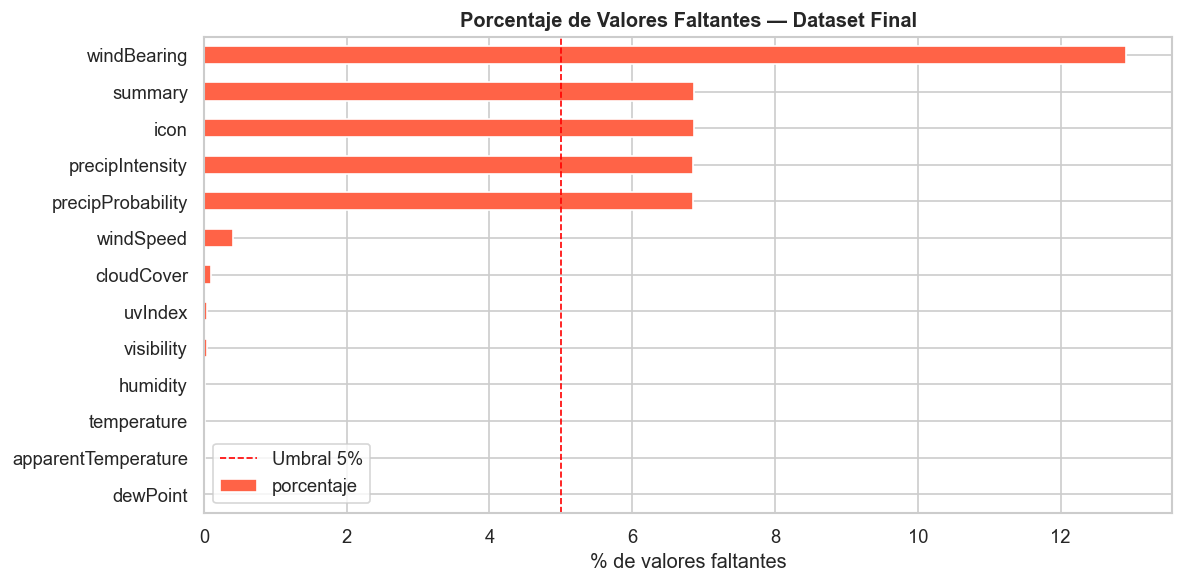

In [16]:
# =============================================================================
# 3. DUPLICADOS
# =============================================================================

print("\n" + "=" * 60)
print("3. DUPLICADOS")
print("=" * 60)

# Duplicados exactos (todas las columnas)
for nombre, tabla in [('accidentes', accidentes), ('clima', clima), ('raw', raw)]:
    dup_total = tabla.duplicated().sum()
    print(f"\n[{nombre}]  Filas duplicadas (exactas): {dup_total}")

# Duplicados en llave de cruce
dup_acc  = accidentes.duplicated(subset=['TW', 'BARRIO']).sum()
dup_cli  = clima.duplicated(subset=['TW', 'BARRIO']).sum()
dup_df   = df.duplicated(subset=['TW', 'BARRIO']).sum()

print(f"\nDuplicados en (TW, BARRIO):")
print(f"  accidentes: {dup_acc}")
print(f"  clima:      {dup_cli}")
print(f"  df final:   {dup_df}")

# Si hay duplicados en clima los eliminamos
if dup_cli > 0:
    clima = clima.drop_duplicates(subset=['TW', 'BARRIO'])
    print(f"  → Duplicados en clima eliminados. Nuevo tamaño: {len(clima)}")

# =============================================================================
# 4. VALORES FALTANTES
# =============================================================================

print("\n" + "=" * 60)
print("4. VALORES FALTANTES")
print("=" * 60)

def reporte_nulos(tabla, nombre):
    nulos = tabla.isnull().sum()
    pct   = (nulos / len(tabla) * 100).round(2)
    reporte = pd.DataFrame({'faltantes': nulos, 'porcentaje': pct})
    reporte = reporte[reporte['faltantes'] > 0].sort_values('porcentaje', ascending=False)
    print(f"\n[{nombre}] — {len(reporte)} columnas con nulos:")
    print(reporte if len(reporte) > 0 else "  Sin valores faltantes.")
    return reporte

nulos_acc = reporte_nulos(accidentes, 'accidentes')
nulos_cli = reporte_nulos(clima,      'clima')
nulos_raw = reporte_nulos(raw,        'raw_accidentes')
nulos_df  = reporte_nulos(df,         'df final')

# Visualización de nulos en el dataset final
if nulos_df is not None and len(nulos_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    nulos_df['porcentaje'].sort_values().plot(
        kind='barh', ax=ax, color='tomato', edgecolor='white')
    ax.set_title('Porcentaje de Valores Faltantes — Dataset Final', fontweight='bold')
    ax.set_xlabel('% de valores faltantes')
    ax.axvline(5, color='red', linestyle='--', linewidth=1, label='Umbral 5%')
    ax.legend()
    plt.tight_layout()
    plt.show()

**Análisis de Outliers**


5. VALORES ATÍPICOS EN VARIABLES CLIMÁTICAS
                       min      Q1  mediana       Q3      max  límite_inf  \
temperature          4.510  16.830  18.6100  22.5200  35.9900       8.295   
apparentTemperature  4.510  16.890  18.7100  22.6000  38.0600       8.325   
dewPoint             2.160  13.000  14.4200  15.7900  24.0400       8.815   
humidity             0.170   0.640   0.7400   0.8500   1.0000       0.325   
precipIntensity      0.000   0.000   0.0302   0.6058  20.8236      -0.909   
precipProbability    0.000   0.000   0.0600   0.2600   1.0000      -0.390   
windSpeed            0.000   0.810   1.3600   2.0900  15.2600      -1.110   
cloudCover           0.000   0.520   0.7500   0.9000   1.0000      -0.050   
uvIndex              0.000   0.000   0.0000   4.0000  14.0000      -6.000   
visibility           0.099  10.003  10.0030  15.0200  16.0930       2.478   

                     límite_sup  outliers_n  outliers_%  
temperature              31.055       912.0      

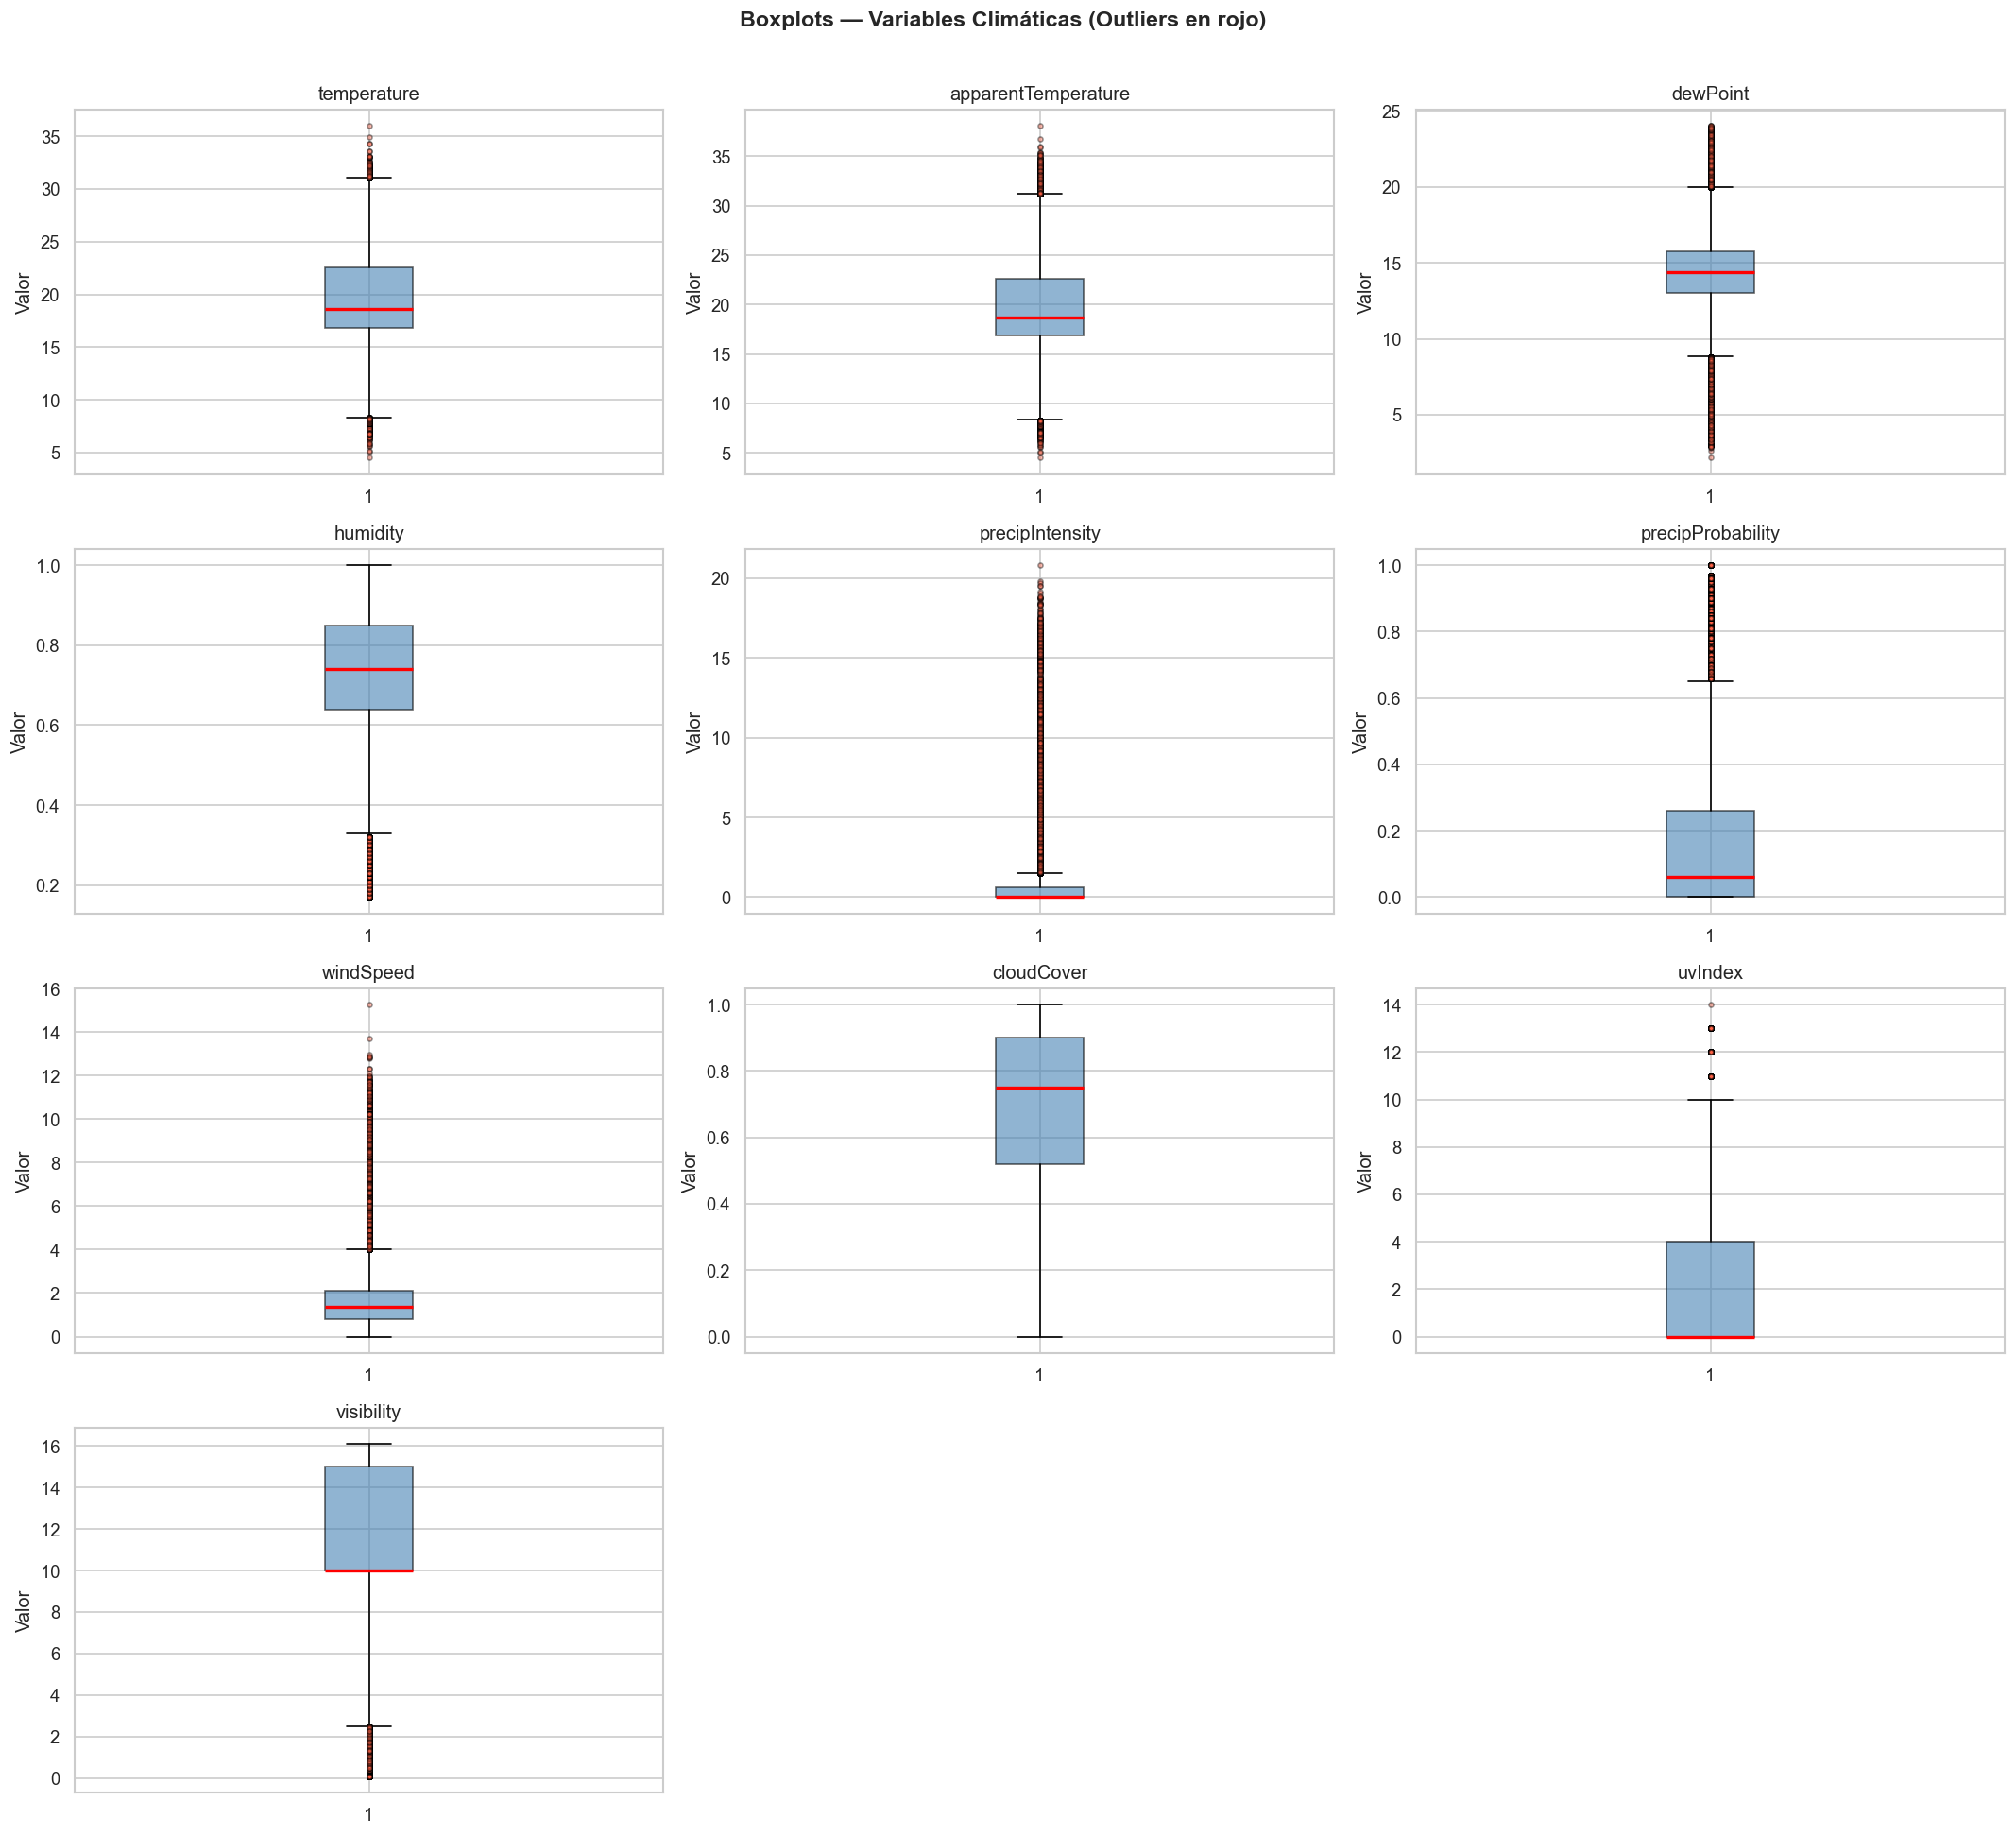

In [17]:
# =============================================================================
# 5. VALORES ATÍPICOS (OUTLIERS)
# =============================================================================

print("\n" + "=" * 60)
print("5. VALORES ATÍPICOS EN VARIABLES CLIMÁTICAS")
print("=" * 60)

vars_clima = ['temperature', 'apparentTemperature', 'dewPoint', 'humidity',
              'precipIntensity', 'precipProbability', 'windSpeed',
              'cloudCover', 'uvIndex', 'visibility']
vars_clima = [v for v in vars_clima if v in df.columns]

def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()
    return pd.Series({
        'min': serie.min(), 'Q1': Q1, 'mediana': serie.median(),
        'Q3': Q3, 'max': serie.max(),
        'límite_inf': round(limite_inf, 3),
        'límite_sup': round(limite_sup, 3),
        'outliers_n': outliers,
        'outliers_%': round(outliers / len(serie) * 100, 2)
    })

resumen_outliers = df[vars_clima].apply(detectar_outliers_iqr).T
print(resumen_outliers)

# Boxplots de variables climáticas para visualizar outliers
ncols = 3
nrows = (len(vars_clima) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, var in enumerate(vars_clima):
    axes[i].boxplot(df[var].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=3,
                                    markerfacecolor='tomato', alpha=0.4))
    axes[i].set_title(var)
    axes[i].set_ylabel('Valor')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — Variables Climáticas (Outliers en rojo)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Validación del Cruce y Resumen**

In [18]:
# =============================================================================
# 6. VALIDACIÓN DEL CRUCE FINAL
# =============================================================================

print("\n" + "=" * 60)
print("6. VALIDACIÓN DEL CRUCE FINAL")
print("=" * 60)

# ¿Cuántos positivos del dataset final realmente cruzaron con clima?
positivos_en_df = df[df['target'] == 1]
print(f"Positivos en df final:                {len(positivos_en_df):,}")
print(f"Positivos originales en accidentes:   {len(accidentes[['TW', 'BARRIO']].drop_duplicates()):,}")

perdidos = len(accidentes[['TW', 'BARRIO']].drop_duplicates()) - len(positivos_en_df)
print(f"Positivos perdidos en el cruce:       {perdidos:,}")
if perdidos > 0:
    print("  → Revisar inconsistencias de BARRIO o TW entre las tablas.")

# Resumen final de decisiones tomadas
print("\n" + "=" * 60)
print("RESUMEN DE DECISIONES DE CALIDAD")
print("=" * 60)
print("""
  1. TW estandarizado a hora exacta con dt.floor('h') en todas las tablas.
  2. BARRIO estandarizado con strip() + upper() para evitar discrepancias.
  3. Duplicados en llave (TW, BARRIO) eliminados de clima si los hubiera.
  4. Valores faltantes identificados por columna y porcentaje.
  5. Outliers detectados con método IQR — se mantienen para el modelo
     basado en árboles (Random Forest, Gradient Boosting) que son robustos
     a outliers; se revisará en feature engineering si se usa regresión logística.
  6. Positivos perdidos en el cruce verificados — indica si hay barrios
     en accidentes que no tienen cobertura climática.
  7. precipIntensity y precipProbability imputadas con 0: ausencia de dato
     meteorológico equivale operacionalmente a ausencia de lluvia.
     Esta es una decisión de dominio, no estadística, por lo que se aplica
     antes de la partición sin riesgo de fuga de información.
""")

# =============================================================================
# 7. IMPUTACIÓN TEMPRANA — DECISIÓN DE DOMINIO
# =============================================================================
# precipIntensity y precipProbability: NaN significa ausencia de registro
# meteorológico, que operacionalmente equivale a 'sin lluvia' → imputar con 0.
# Esta decisión es de dominio (no se aprende de los datos), por lo que es
# seguro aplicarla antes de la partición train/val/test.
cols_precip = ['precipIntensity', 'precipProbability']
for col in cols_precip:
    if col in df.columns:
        n_nulos = df[col].isnull().sum()
        df[col] = df[col].fillna(0)
        print(f'  {col}: {n_nulos:,} NaN → 0')

print('\n✅ Imputación de precipitación completada.')
print('   Nota: las demás variables climáticas (windSpeed, cloudCover, etc.)')
print('   se imputarán con la mediana del conjunto de entrenamiento en la')
print('   sección 4.4, para evitar fuga de información hacia val/test.')


6. VALIDACIÓN DEL CRUCE FINAL
Positivos en df final:                120,475
Positivos originales en accidentes:   120,587
Positivos perdidos en el cruce:       112
  → Revisar inconsistencias de BARRIO o TW entre las tablas.

RESUMEN DE DECISIONES DE CALIDAD

  1. TW estandarizado a hora exacta con dt.floor('h') en todas las tablas.
  2. BARRIO estandarizado con strip() + upper() para evitar discrepancias.
  3. Duplicados en llave (TW, BARRIO) eliminados de clima si los hubiera.
  4. Valores faltantes identificados por columna y porcentaje.
  5. Outliers detectados con método IQR — se mantienen para el modelo
     basado en árboles (Random Forest, Gradient Boosting) que son robustos
     a outliers; se revisará en feature engineering si se usa regresión logística.
  6. Positivos perdidos en el cruce verificados — indica si hay barrios
     en accidentes que no tienen cobertura climática.
  7. precipIntensity y precipProbability imputadas con 0: ausencia de dato
     meteorológico equi

## Análisis Exploratorio 

**Temporal y Espacial**

C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\2213698599.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=accidentes_pos, x='hora', ax=axes[0], palette='viridis')


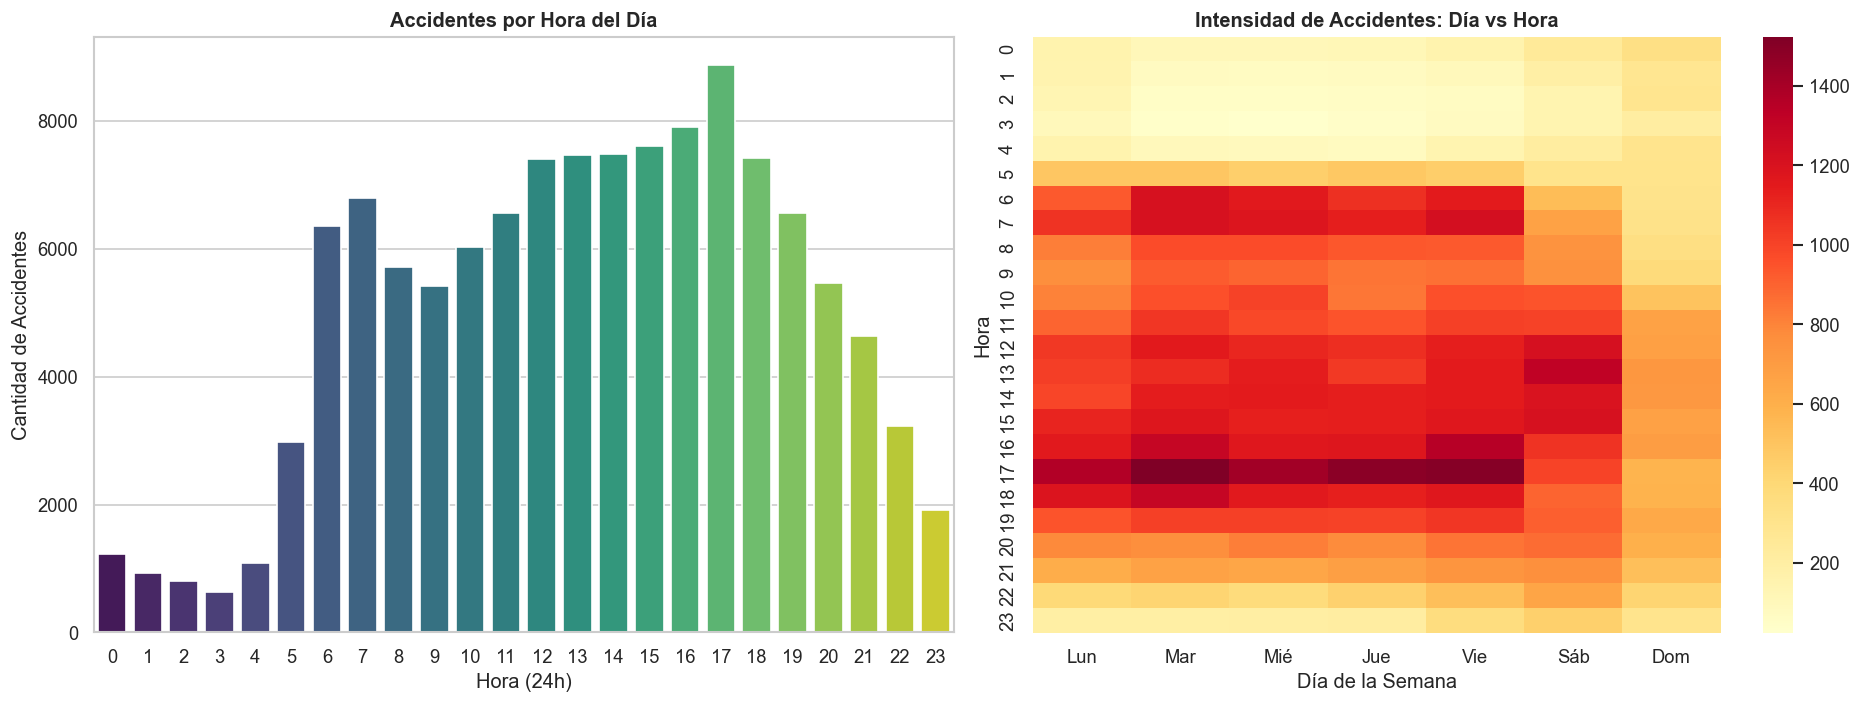

C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\2213698599.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tasa['tasa'], y=top_tasa.index, palette='magma')


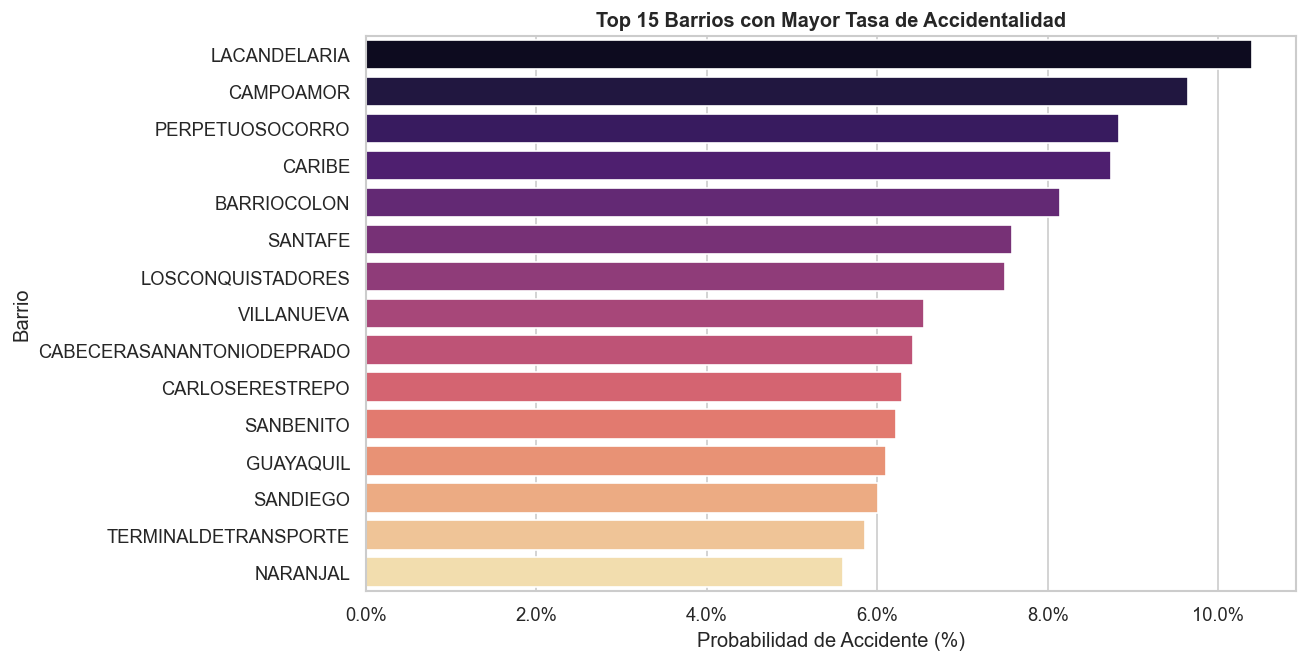

In [19]:
# ==========================================
# 3. EDA: ANÁLISIS TEMPORAL Y ESPACIAL
# ==========================================

# 3.1 Preparación de datos para visualización
accidentes_pos = df[df['target'] == 1].copy()
accidentes_pos['hora'] = accidentes_pos['TW'].dt.hour
accidentes_pos['dia_sem'] = accidentes_pos['TW'].dt.dayofweek # 0=Lunes, 6=Domingo

# --- Gráficos Temporales ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accidentes por Hora
sns.countplot(data=accidentes_pos, x='hora', ax=axes[0], palette='viridis')
axes[0].set_title('Accidentes por Hora del Día', fontweight='bold')
axes[0].set_xlabel('Hora (24h)')
axes[0].set_ylabel('Cantidad de Accidentes')

# Heatmap Hora vs Día de la Semana
dias_es = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
pivot_h_d = accidentes_pos.groupby(['hora', 'dia_sem'])['target'].count().unstack()
sns.heatmap(pivot_h_d, cmap='YlOrRd', ax=axes[1], xticklabels=dias_es)
axes[1].set_title('Intensidad de Accidentes: Día vs Hora', fontweight='bold')
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Hora')

plt.tight_layout()
plt.show()

# --- 3.2 Análisis Espacial (Tasa por Barrio) ---
# Calculamos la tasa para ver dónde es proporcionalmente más peligroso
stats_barrio = df.groupby('BARRIO')['target'].agg(['count', 'sum'])
stats_barrio.columns = ['total_horas', 'accidentes']
stats_barrio['tasa'] = stats_barrio['accidentes'] / stats_barrio['total_horas']

top_tasa = stats_barrio.sort_values('tasa', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_tasa['tasa'], y=top_tasa.index, palette='magma')
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.title('Top 15 Barrios con Mayor Tasa de Accidentalidad', fontweight='bold')
plt.xlabel('Probabilidad de Accidente (%)')
plt.ylabel('Barrio')
plt.show()

**Análisis Exploratorio- Clima**

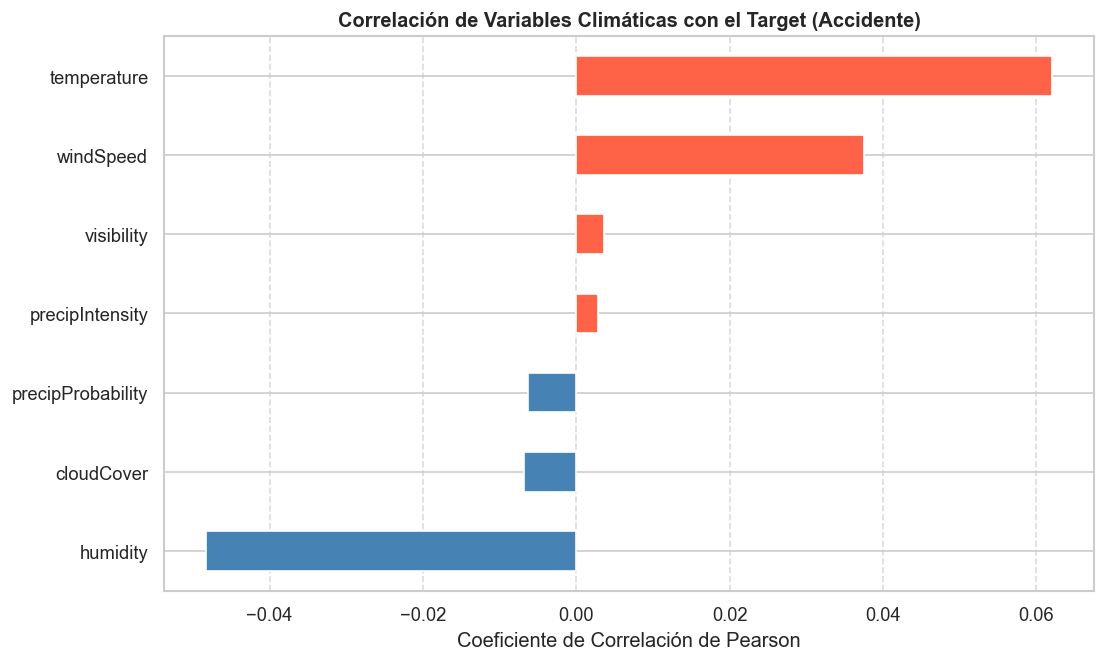

C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\1130256959.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='humidity', ax=axes[0], palette='Set2')
C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\1130256959.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sin Accidente', 'Con Accidente'])
C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\1130256959.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='precipIntensity', ax=axes[1], palette='Set2')
C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\1130256959.py:33: UserWarning: se

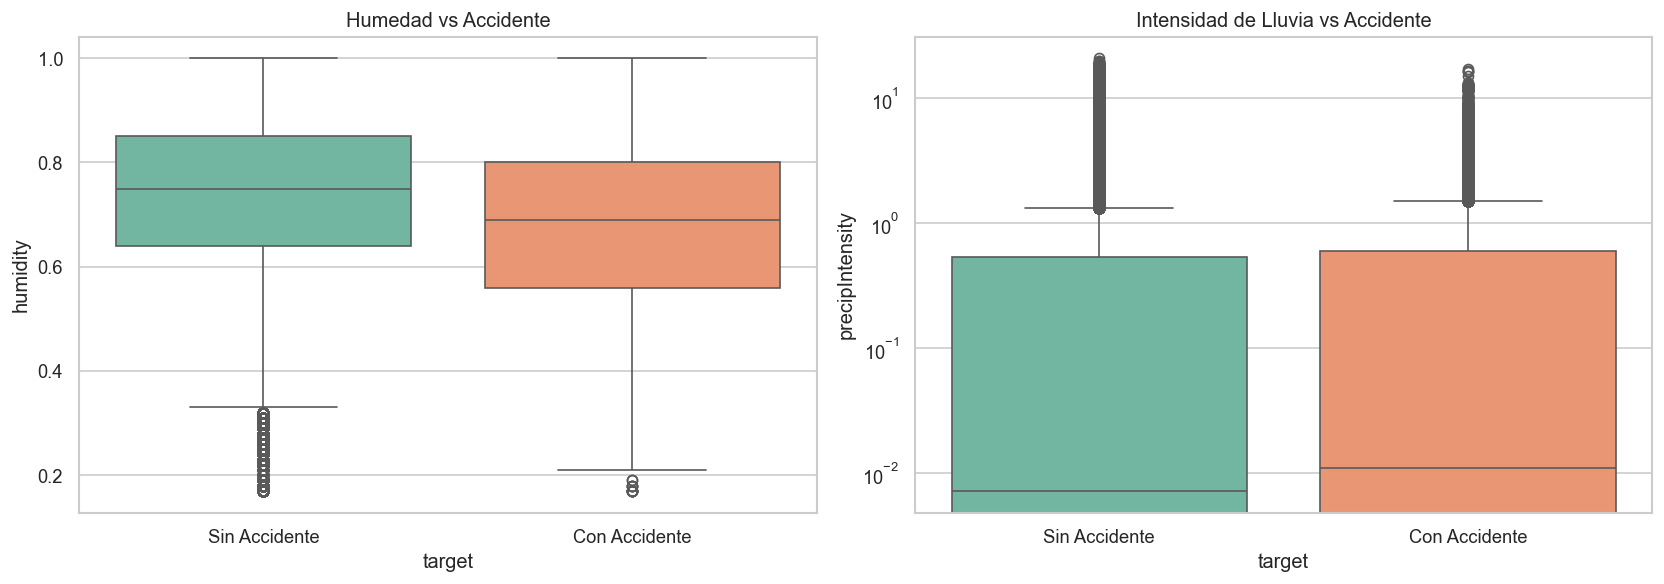

Promedio de variables climáticas según presencia de accidente:


,temperature,humidity,precipIntensity,precipProbability,windSpeed,visibility,cloudCover
target,,,,,,,
0,19.624997,0.735288,0.443226,0.148826,1.576782,11.316265,0.722608
1,21.535629,0.673776,0.463434,0.137747,1.963154,11.417221,0.711025


In [20]:
# ==========================================
# 4. EDA: ANÁLISIS CLIMÁTICO
# ==========================================

# 4.1 Selección de variables climáticas
vars_clima = ['temperature', 'humidity', 'precipIntensity', 'precipProbability',
              'windSpeed', 'visibility', 'cloudCover', 'pressure']

# Asegurar que solo usamos las que están en el DF
vars_clima = [v for v in vars_clima if v in df.columns]

# --- Gráfico de Correlación ---
plt.figure(figsize=(10, 6))
correlaciones = df[vars_clima + ['target']].corr()['target'].drop('target').sort_values()
colores = ['tomato' if c > 0 else 'steelblue' for c in correlaciones]

correlaciones.plot(kind='barh', color=colores, edgecolor='white')
plt.title('Correlación de Variables Climáticas con el Target (Accidente)', fontweight='bold')
plt.xlabel('Coeficiente de Correlación de Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- Análisis de Distribución (Boxplots) ---
# Vamos a ver cómo cambia la humedad y la lluvia ante un accidente
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='target', y='humidity', ax=axes[0], palette='Set2')
axes[0].set_title('Humedad vs Accidente')
axes[0].set_xticklabels(['Sin Accidente', 'Con Accidente'])

sns.boxplot(data=df, x='target', y='precipIntensity', ax=axes[1], palette='Set2')
axes[1].set_title('Intensidad de Lluvia vs Accidente')
axes[1].set_xticklabels(['Sin Accidente', 'Con Accidente'])
axes[1].set_yscale('log') # Escala logarítmica para ver mejor la lluvia

plt.tight_layout()
plt.show()

# Resumen Estadístico
print("Promedio de variables climáticas según presencia de accidente:")
display(df.groupby('target')[vars_clima].mean())

**Accidentes por mes**

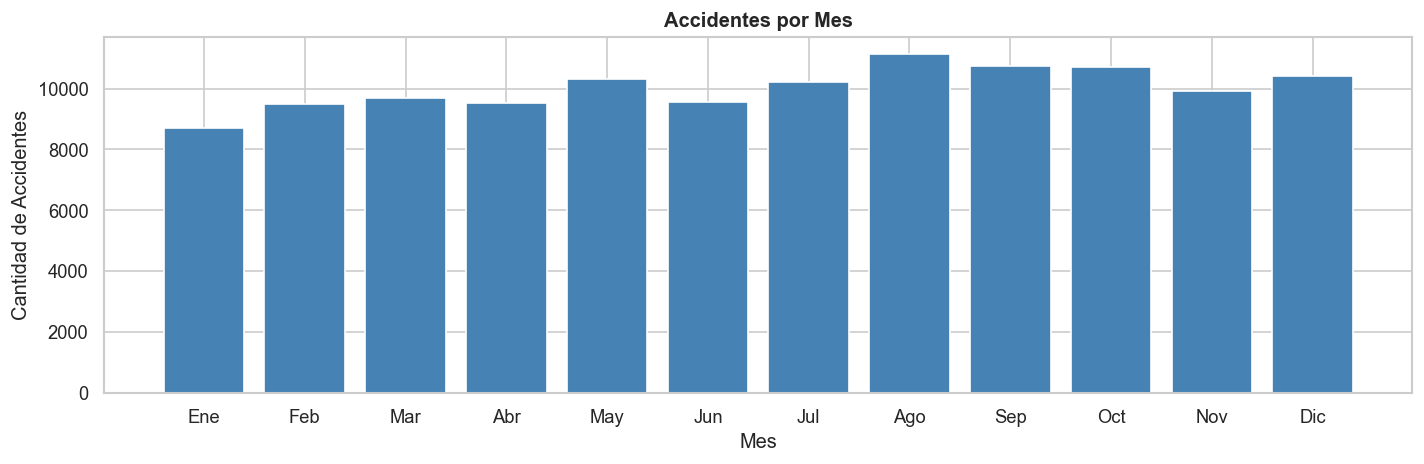

Mes con mas accidentes:   Ago (11,158)
Mes con menos accidentes: Ene (8,695)


In [21]:
# ==========================================
#  ACCIDENTES POR MES
# ==========================================

accidentes_pos = df[df['target'] == 1].copy()
accidentes_pos['mes'] = accidentes_pos['TW'].dt.month

meses_es = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
            7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

conteo_mes = accidentes_pos.groupby('mes')['target'].count()

plt.figure(figsize=(12, 4))
plt.bar(conteo_mes.index, conteo_mes.values, color='steelblue', edgecolor='white')
plt.xticks(list(meses_es.keys()), list(meses_es.values()))
plt.title('Accidentes por Mes', fontweight='bold')
plt.xlabel('Mes')
plt.ylabel('Cantidad de Accidentes')
plt.tight_layout()
plt.show()

mes_pico = meses_es[conteo_mes.idxmax()]
mes_bajo = meses_es[conteo_mes.idxmin()]
print(f"Mes con mas accidentes:   {mes_pico} ({conteo_mes.max():,})")
print(f"Mes con menos accidentes: {mes_bajo} ({conteo_mes.min():,})")

**Analisis desde raw_accidentes**

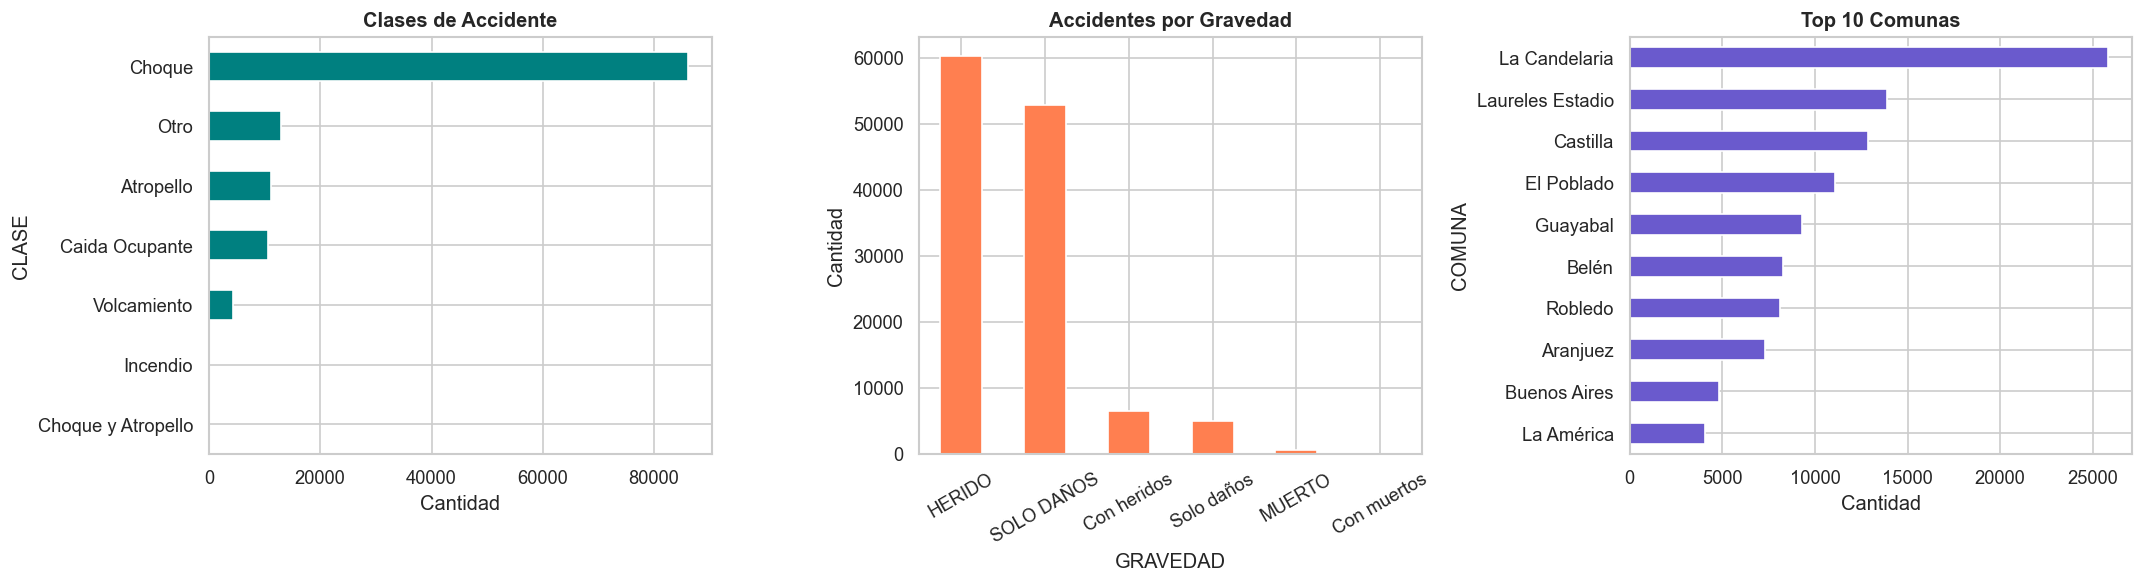

Clases mas frecuentes:
CLASE
Choque                86068
Otro                  12947
Atropello             11199
Caida Ocupante        10546
Volcamiento            4342
Incendio                 19
Choque y Atropello        1

Gravedad mas comun: HERIDO (60,162 casos)
Comuna con mas accidentes: La Candelaria (25,844 casos)


In [22]:
# ==========================================
# 5.2 ANALISIS DESDE raw_accidentes
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
raw['CLASE'] = raw['CLASE'].str.strip()
raw['CLASE'] = raw['CLASE'].replace({'Caída Ocupante':'Caida Ocupante'})

# Clase de accidente
conteo_clase = raw['CLASE'].value_counts().head(10)
conteo_clase.plot(kind='barh', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Clases de Accidente', fontweight='bold')
axes[0].set_xlabel('Cantidad')
axes[0].invert_yaxis()

# Gravedad
conteo_grav = raw['GRAVEDAD'].value_counts()
conteo_grav.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white', rot=30)
axes[1].set_title('Accidentes por Gravedad', fontweight='bold')
axes[1].set_ylabel('Cantidad')

# Top comunas
conteo_comuna = raw['COMUNA'].value_counts().head(10)
conteo_comuna.plot(kind='barh', ax=axes[2], color='slateblue', edgecolor='white')
axes[2].set_title('Top 10 Comunas', fontweight='bold')
axes[2].set_xlabel('Cantidad')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print("Clases mas frecuentes:")
print(conteo_clase.to_string())
print(f"\nGravedad mas comun: {conteo_grav.idxmax()} ({conteo_grav.max():,} casos)")
print(f"Comuna con mas accidentes: {conteo_comuna.idxmax()} ({conteo_comuna.max():,} casos)")

**Desbalance de clases**

Clase positiva (con accidente):    0.0151  (1.51%)
Clase negativa (sin accidente):    0.9849  (98.49%)
Ratio de desbalance: 1:65.3  (1 positivo por cada 65.3 negativos)


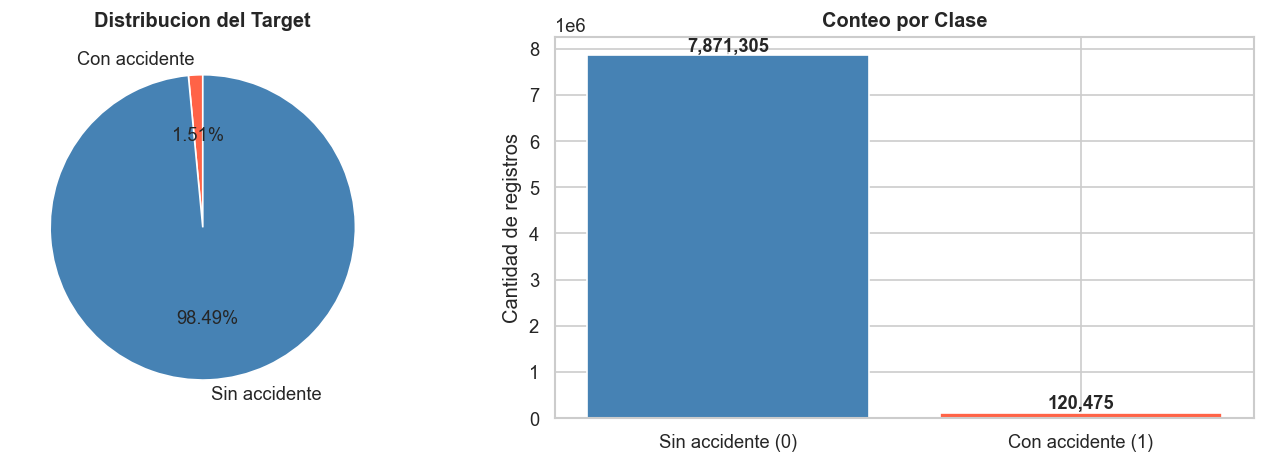


Conclusion: El desbalance marcado justifica:
  - No usar accuracy como metrica principal.
  - Aplicar estrategias de balanceo (SMOTE, class_weight, undersampling).
  - Evaluar con F1-Score, ROC-AUC y PR-AUC.



In [23]:
# ==========================================
# 5.3 DESBALANCE DE CLASES
# ==========================================

prop_pos = df['target'].mean()
prop_neg = 1 - prop_pos
ratio    = prop_neg / prop_pos

print(f"Clase positiva (con accidente):    {prop_pos:.4f}  ({prop_pos*100:.2f}%)")
print(f"Clase negativa (sin accidente):    {prop_neg:.4f}  ({prop_neg*100:.2f}%)")
print(f"Ratio de desbalance: 1:{ratio:.1f}  (1 positivo por cada {ratio:.1f} negativos)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafico de torta
axes[0].pie([prop_pos, prop_neg],
            labels=['Con accidente', 'Sin accidente'],
            autopct='%1.2f%%',
            colors=['tomato', 'steelblue'],
            startangle=90)
axes[0].set_title('Distribucion del Target', fontweight='bold')

# Barras de conteo
conteos = df['target'].value_counts().sort_index()
axes[1].bar(['Sin accidente (0)', 'Con accidente (1)'],
            conteos.values,
            color=['steelblue', 'tomato'],
            edgecolor='white')
for i, v in enumerate(conteos.values):
    axes[1].text(i, v + conteos.max()*0.01, f'{v:,}', ha='center', fontweight='bold')
axes[1].set_title('Conteo por Clase', fontweight='bold')
axes[1].set_ylabel('Cantidad de registros')

plt.tight_layout()
plt.show()

print("""
Conclusion: El desbalance marcado justifica:
  - No usar accuracy como metrica principal.
  - Aplicar estrategias de balanceo (SMOTE, class_weight, undersampling).
  - Evaluar con F1-Score, ROC-AUC y PR-AUC.
""")

## 4.3 Unión de tablas e ingeniería de características

### Unión de tablas y justificación del JOIN

La unión ya se realizó dentro de `construir_dataset_maestro()`, pero aquí se documenta explícitamente la decisión:

```python
df_final = pd.merge(clima, positivos, on=['TW', 'BARRIO'], how='left')
```

**¿Por qué LEFT JOIN?**

| Tipo | Resultado | ¿Aplica? |
|------|-----------|----------|
| `LEFT` (clima → positivos) | Conserva **todas** las filas de `clima` (universo completo de horas-barrio). Las filas sin accidente quedan con `target = 0`. | ✅ **Elegido** |
| `INNER` | Solo conservaría las horas-barrio con accidente — eliminaría todos los casos negativos que necesitamos construir. | ❌ |
| `RIGHT` | Equivale a un INNER aquí porque `positivos` solo tiene horas con accidente. | ❌ |
| `OUTER` | No aporta nada adicional: `clima` ya cubre todas las combinaciones. | ❌ |

**Conclusión:** el universo de predicción lo define `clima` (todas las combinaciones barrio × hora). El `target = 1` donde esa combinación aparece en `accidentes`, y `target = 0` en el resto. Un LEFT JOIN desde `clima` garantiza esto sin perder ningún caso negativo.

### Variables temporales y festivos

Se extraen componentes de `TW` y se identifican festivos colombianos. Los festivos y fines de semana alteran el patrón de movilidad y, por tanto, la accidentalidad.

In [24]:
def agregar_features_temporales(df_input):
    """
    Extrae variables temporales desde TW.

    Salidas: hora, dia, mes, anio, dia_sem (0=Lun),
             dia_anio, es_fin_semana, es_festivo, periodo_dia.
    """
    df_out = df_input.copy()

    df_out['hora']     = df_out['TW'].dt.hour
    df_out['dia']      = df_out['TW'].dt.day
    df_out['mes']      = df_out['TW'].dt.month
    df_out['anio']     = df_out['TW'].dt.year
    df_out['dia_sem']  = df_out['TW'].dt.dayofweek   # 0=Lunes … 6=Domingo
    df_out['dia_anio'] = df_out['TW'].dt.dayofyear

    # Fin de semana: sábado (5) o domingo (6)
    df_out['es_fin_semana'] = (df_out['dia_sem'] >= 5).astype(int)

    # Festivos Colombia — solo años presentes en los datos
    anos = df_out['anio'].unique().tolist()
    festivos_col = holidays.Colombia(years=anos)
    df_out['es_festivo'] = df_out['TW'].dt.date.map(
        lambda d: 1 if d in festivos_col else 0
    )

    # Período del día (4 franjas operacionalmente relevantes)
    def _periodo(h):
        if   0 <= h <  6: return 'madrugada'
        elif 6 <= h < 12: return 'manana'
        elif 12 <= h < 18: return 'tarde'
        else:              return 'noche'

    df_out['periodo_dia'] = df_out['hora'].map(_periodo)
    return df_out


df_feat = agregar_features_temporales(df)

cols_check = ['hora', 'mes', 'dia_sem', 'es_fin_semana', 'es_festivo', 'periodo_dia']
print('Muestra de variables temporales:')
print(df_feat[cols_check].head(4).to_string())
print(f'\nFestivos en el dataset: {df_feat["es_festivo"].sum():,} registros')
print(f'Fin de semana:          {df_feat["es_fin_semana"].sum():,} registros')

Muestra de variables temporales:
   hora  mes  dia_sem  es_fin_semana  es_festivo periodo_dia
0     0    1        6              1           1   madrugada
1     1    1        6              1           1   madrugada
2     2    1        6              1           1   madrugada
3     3    1        6              1           1   madrugada

Festivos en el dataset: 386,654 registros
Fin de semana:          2,284,458 registros


### Codificación cíclica (seno / coseno)

Variables como `hora` o `dia_sem` son periódicas: hora 23 y hora 0 son consecutivas, pero numéricamente distan 23 unidades. La codificación sin/cos las proyecta al círculo unitario, preservando esa continuidad para modelos lineales y de distancia.

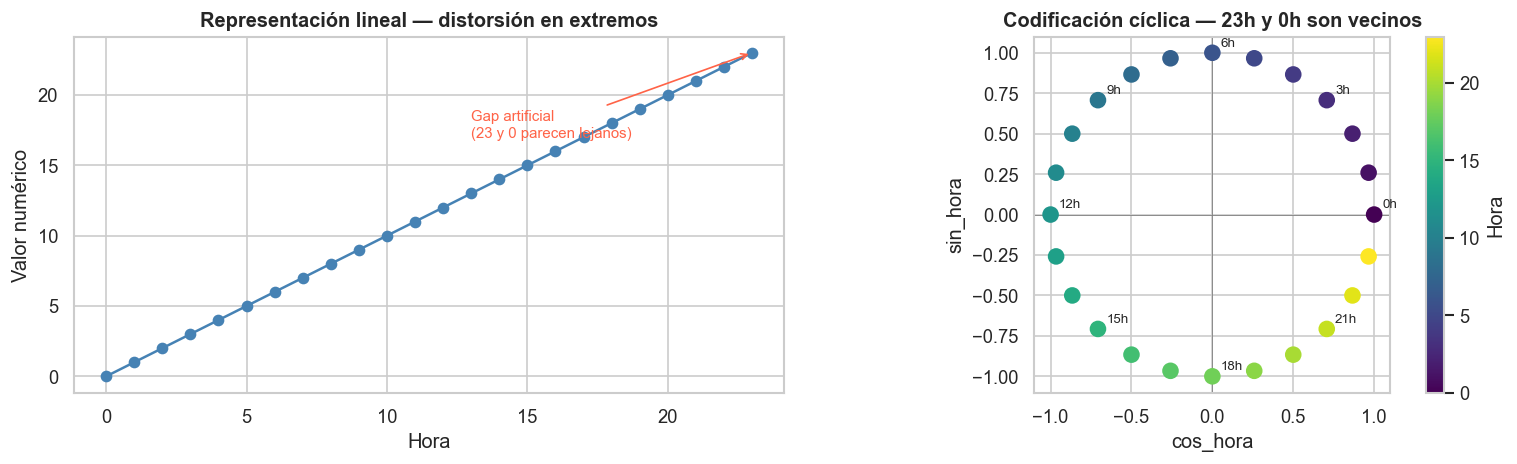

Columnas cíclicas creadas (8): ['sin_hora', 'cos_hora', 'sin_dia_sem', 'cos_dia_sem', 'sin_mes', 'cos_mes', 'sin_dia_anio', 'cos_dia_anio']


In [25]:
def agregar_features_ciclicas(df_input):
    """
    Codifica variables periódicas con sin/cos.
    Pares creados: hora (24h), dia_sem (7d), mes (12m), dia_anio (365d).
    """
    df_out = df_input.copy()
    ciclos = {'hora': 24, 'dia_sem': 7, 'mes': 12, 'dia_anio': 365}
    for col, periodo in ciclos.items():
        df_out[f'sin_{col}'] = np.sin(2 * np.pi * df_out[col] / periodo)
        df_out[f'cos_{col}'] = np.cos(2 * np.pi * df_out[col] / periodo)
    return df_out


df_feat = agregar_features_ciclicas(df_feat)

# --- Visualización: lineal vs cíclico ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

horas = np.arange(0, 24)
axes[0].plot(horas, horas, 'o-', color='steelblue')
axes[0].annotate('Gap artificial\n(23 y 0 parecen lejanos)',
    xy=(23, 23), xytext=(13, 17),
    arrowprops=dict(arrowstyle='->', color='tomato'), color='tomato', fontsize=9)
axes[0].set_title('Representación lineal — distorsión en extremos', fontweight='bold')
axes[0].set_xlabel('Hora'); axes[0].set_ylabel('Valor numérico')

sin_h = np.sin(2 * np.pi * horas / 24)
cos_h = np.cos(2 * np.pi * horas / 24)
sc = axes[1].scatter(cos_h, sin_h, c=horas, cmap='viridis', s=80, zorder=3)
for i in range(0, 24, 3):
    axes[1].annotate(f'{i}h', (cos_h[i], sin_h[i]),
                     textcoords='offset points', xytext=(5, 4), fontsize=8)
plt.colorbar(sc, ax=axes[1], label='Hora')
axes[1].set_title('Codificación cíclica — 23h y 0h son vecinos', fontweight='bold')
axes[1].set_xlabel('cos_hora'); axes[1].set_ylabel('sin_hora')
axes[1].set_aspect('equal')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].axvline(0, color='gray', lw=0.5)
plt.tight_layout(); plt.show()

cols_cic = [c for c in df_feat.columns if c.startswith(('sin_', 'cos_'))]
print(f'Columnas cíclicas creadas ({len(cols_cic)}): {cols_cic}')

### Variables históricas por barrio — sin *data leakage*

**Regla clave:** para cada fila en el momento **T**, la variable histórica se calcula usando **solo** observaciones con `TW < T`. Se logra ordenando el dataset por `TW` y aplicando `shift(1).expanding()` dentro de cada grupo. Las primeras filas de cada barrio (sin historial aún) reciben la media global como valor por defecto.

Variables creadas:
- `tasa_hist_barrio`: proporción histórica de horas con accidente en ese barrio.
- `tasa_hist_barrio_hora`: ídem, pero segmentado por hora del día (más granular).
- `acc_hist_acum`: conteo acumulado de accidentes en ese barrio hasta T.
- `comuna_barrio`: comuna asociada al barrio (desde `raw_accidentes`).

Calculando variables históricas...

Verificación anti-leakage:
  Media global del target:                    0.015075
  Barrios con primera fila = media global:    100.0% ✅


C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\918791238.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='target', y=col, palette='Set2', ax=ax)
C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\918791238.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Sin accidente (0)', 'Con accidente (1)'])
C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\918791238.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feat, x='target', y=col, palette='Set2', ax=ax)
C:\Users\Juli\AppData\Local\Temp\ipykernel_27948\918791238.py:65: UserWarning: set_ticklabels() should 

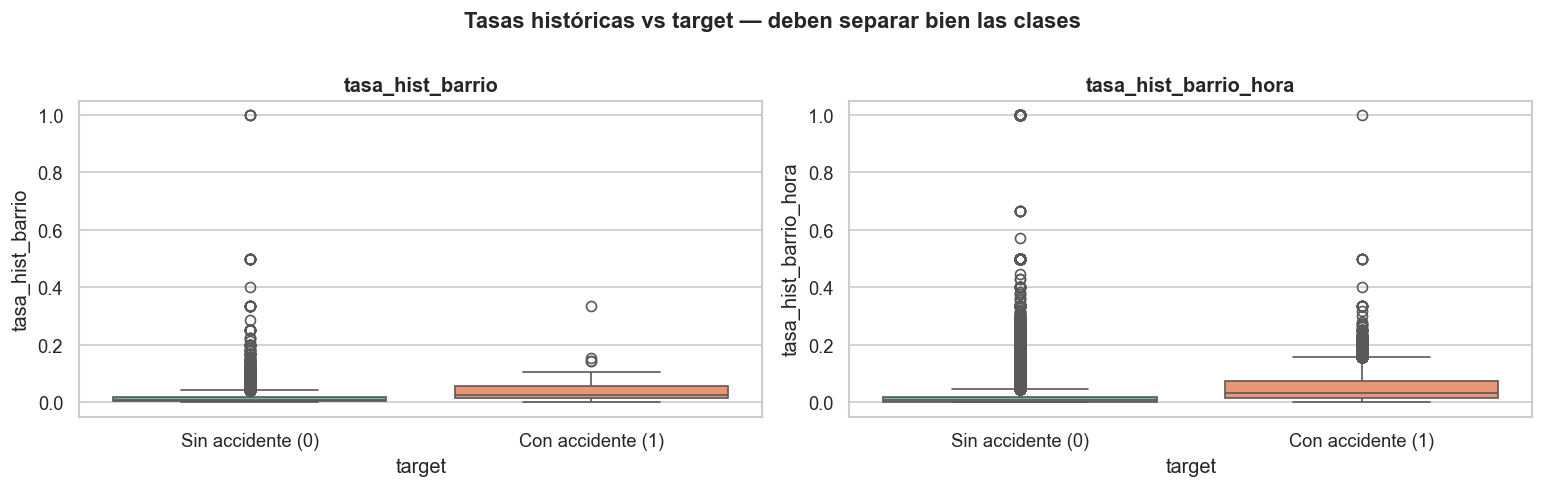


Comunas detectadas: 27


In [26]:
def agregar_features_historicas(df_input, raw_input):
    """
    Calcula variables históricas sin fuga de información temporal.

    Usa shift(1).expanding() sobre el dataset ordenado por TW, de modo
    que cada fila solo ve datos anteriores a su propio instante T.

    Nota de rendimiento: con ~8M filas puede tardar 1-2 min.
    Para pruebas rápidas: df_input.sample(frac=0.1, random_state=42)
    """
    # Ordenar cronológicamente — obligatorio para que shift(1) sea correcto
    df_out = df_input.sort_values('TW').reset_index(drop=True).copy()
    media_global = df_out['target'].mean()

    # 1. Tasa histórica de accidentalidad por barrio
    df_out['tasa_hist_barrio'] = (
        df_out.groupby('BARRIO')['target']
        .transform(lambda x: x.shift(1).expanding().mean())
        .fillna(media_global)   # sin historial → media global como prior
    )

    # 2. Conteo acumulado de accidentes por barrio
    df_out['acc_hist_acum'] = (
        df_out.groupby('BARRIO')['target']
        .transform(lambda x: x.shift(1).cumsum())
        .fillna(0)
    )

    # 3. Tasa histórica por barrio x hora del día (más granular)
    df_out['tasa_hist_barrio_hora'] = (
        df_out.groupby(['BARRIO', 'hora'])['target']
        .transform(lambda x: x.shift(1).expanding().mean())
        .fillna(media_global)
    )

    # 4. Comuna por barrio (desde raw_accidentes, sin leakage — es un atributo fijo)
    mapa_comuna = (
        raw_input.dropna(subset=['BARRIO', 'COMUNA'])
        .assign(BARRIO=lambda d: d['BARRIO'].str.strip().str.upper())
        .groupby('BARRIO')['COMUNA']
        .agg(lambda x: x.mode().iloc[0] if len(x) > 0 else None)
    )
    df_out['comuna'] = df_out['BARRIO'].map(mapa_comuna).fillna('DESCONOCIDA')

    return df_out


print('Calculando variables históricas...')
df_feat = agregar_features_historicas(df_feat, raw)

# --- Verificación anti-leakage ---
# La primera aparición de cada barrio DEBE tener tasa = media global
primera_fila = df_feat.groupby('BARRIO')['tasa_hist_barrio'].first()
media_global = df_feat['target'].mean()
pct_ok = (primera_fila.round(6) == round(media_global, 6)).mean() * 100
print(f'\nVerificación anti-leakage:')
print(f'  Media global del target:                    {media_global:.6f}')
print(f'  Barrios con primera fila = media global:    {pct_ok:.1f}% '
      f'{"✅" if pct_ok == 100 else "❌ REVISAR"}')

# --- Poder discriminante ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['tasa_hist_barrio', 'tasa_hist_barrio_hora']):
    sns.boxplot(data=df_feat, x='target', y=col, palette='Set2', ax=ax)
    ax.set_xticklabels(['Sin accidente (0)', 'Con accidente (1)'])
    ax.set_title(col, fontweight='bold')
plt.suptitle('Tasas históricas vs target — deben separar bien las clases',
             fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f'\nComunas detectadas: {df_feat["comuna"].nunique()}')

### Selección de variables climáticas

Basada en el EDA de la sección anterior:

| Variable | Justificación |
|---|---|
| `humidity` | Distribución diferente entre clases (boxplot EDA) |
| `precipIntensity`, `precipProbability` | Lluvia correlaciona con accidentalidad |
| `visibility` | Menor visibilidad → mayor riesgo |
| `windSpeed` | Viento afecta control del vehículo |
| `temperature`, `apparentTemperature` | Contexto térmico |
| `cloudCover`, `dewPoint`, `uvIndex` | Señales de condición meteorológica general |

Se excluyen `windBearing` (dirección del viento, poca relación causal directa) y `pressure` (no está en el esquema original de los datos).

### Codificación de variables categóricas

- **`BARRIO`, `summary`, `icon`:** *Frequency encoding*. One-hot generaría cientos de columnas esparsas; target encoding requiere recalcularse dentro de cada fold para evitar leakage. La frecuencia es un proxy seguro y captura cuán representada está cada categoría.
- **`periodo_dia`:** One-hot (solo 4 categorías, manejable).
- **`comuna`:** Frequency encoding (cardinalidad media).

> **Nota:** en el pipeline de modelado, los mapeos de frecuencia se recalcularán **solo sobre el conjunto de entrenamiento** antes de aplicarse a validación, para evitar leakage.

In [27]:
def codificar_categoricas(df_inout):
    """Modifica el dataframe IN-PLACE para evitar copias en memoria."""
    
    for col in ['BARRIO', 'summary', 'icon', 'comuna']:
        if col in df_inout.columns:
            freq = df_inout[col].value_counts(normalize=True)
            df_inout[f'{col}_freq'] = df_inout[col].map(freq).fillna(0).astype('float32')
            print(f'  {col:<10}: {df_inout[col].nunique():>4} categorías → {col}_freq creada')

    # One-hot manual in-place, dtype int8 (8x menos memoria que int64)
    if 'periodo_dia' in df_inout.columns:
        for cat in ['madrugada', 'manana', 'tarde', 'noche']:
            df_inout[f'periodo_{cat}'] = (df_inout['periodo_dia'] == cat).astype('int8')
        print(f'  periodo_dia → one-hot creado (int8)')

    return df_inout  # misma referencia, sin copia


print('Codificando variables categóricas:')
codificar_categoricas(df_feat)  # modifica df_feat directamente


print('Codificando variables categóricas:')
df_feat = codificar_categoricas(df_feat)

Codificando variables categóricas:
  BARRIO    :  319 categorías → BARRIO_freq creada
  summary   :   20 categorías → summary_freq creada
  icon      :    8 categorías → icon_freq creada
  comuna    :   27 categorías → comuna_freq creada
  periodo_dia → one-hot creado (int8)
Codificando variables categóricas:
  BARRIO    :  319 categorías → BARRIO_freq creada
  summary   :   20 categorías → summary_freq creada
  icon      :    8 categorías → icon_freq creada
  comuna    :   27 categorías → comuna_freq creada
  periodo_dia → one-hot creado (int8)


### Consolidación final — lista `FEATURES`

Se define la lista `FEATURES` con todas las variables del modelo, `TARGET` con la variable objetivo y `COLS_EXCLUIR` con columnas a descartar. Estas tres variables son el punto de entrada de la sección 4.4.

RESUMEN — INGENIERÍA DE CARACTERÍSTICAS
Dataset:           7,991,780 filas x 45 columnas
Features totales:         22
  Climáticas    : 7
  Temporales    : 2
  Cíclicas      : 6
  Históricas    : 3
  Codificadas   : 4

Verificando nulos en FEATURES...
⚠️  Features con nulos (se imputarán en 4.4):
   temperature: 610
   humidity: 915
   windSpeed: 32,793
   cloudCover: 7,950
   visibility: 4,290

Calculando correlaciones...


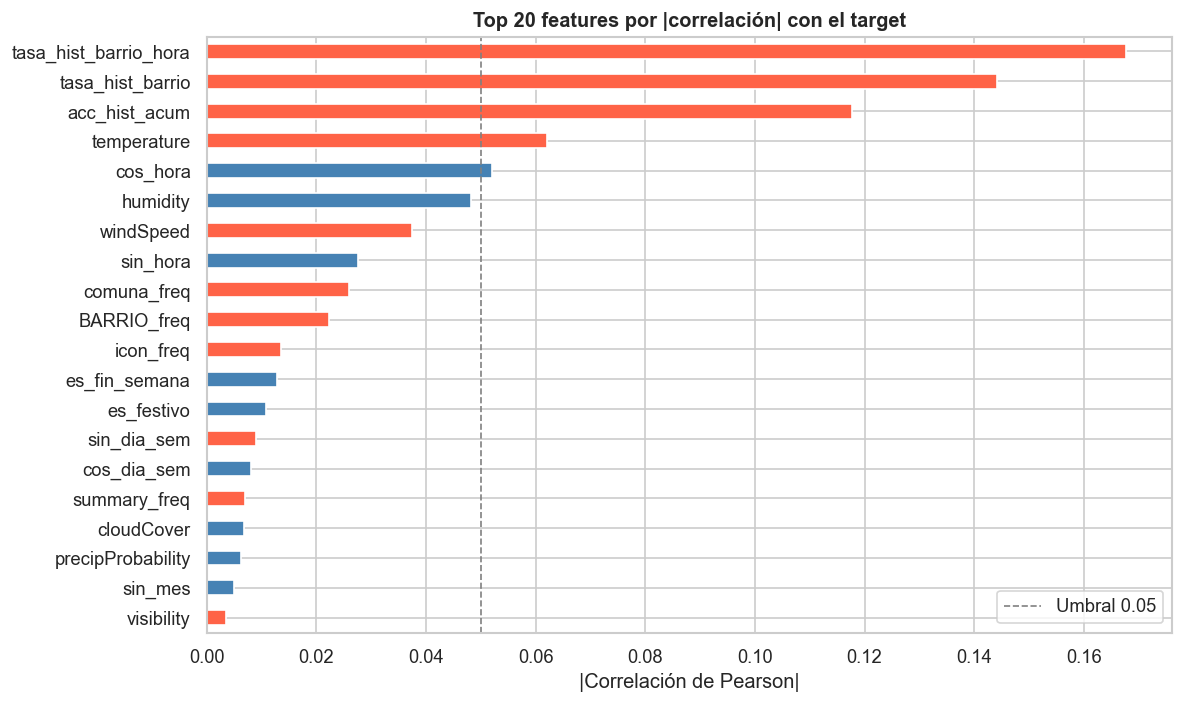


→ FEATURES y TARGET listos para la sección 4.4.


In [28]:
def definir_columnas_modelo(df_input):
    """
    Devuelve FEATURES (lista) y TARGET (str).
    
    Criterios de exclusión aplicados:
    - apparentTemperature: r > 0.97 con temperature → redundante
    - dewPoint: función directa de temperature + humidity → redundante  
    - uvIndex: proxy de hora del día, ya codificada cíclicamente → redundante
    - dia: día del mes, sin relación causal con accidentalidad → ruido
    - dia_anio, sin_dia_anio, cos_dia_anio: redundantes con sin_mes/cos_mes
    - hora, dia_sem, mes (crudos): reemplazados por sus versiones cíclicas
    - periodo_*: redundantes con sin_hora/cos_hora para Random Forest
    """
    vars_clima = [v for v in [
        'temperature',          # ✅ conservar
        # 'apparentTemperature' ❌ r=0.97 con temperature
        'humidity',             # ✅ conservar
        'precipIntensity',      # ✅ conservar
        'precipProbability',    # ✅ conservar
        'windSpeed',            # ✅ conservar
        'cloudCover',           # ✅ conservar
        'visibility',           # ✅ conservar
        # 'dewPoint'            ❌ función de temperature + humidity
        # 'uvIndex'             ❌ proxy de hora, ya codificada
    ] if v in df_input.columns]

    vars_temp = [v for v in [
        # 'hora'     ❌ reemplazada por sin_hora + cos_hora
        # 'dia'      ❌ día del mes, sin relación causal
        # 'mes'      ❌ reemplazado por sin_mes + cos_mes
        # 'dia_sem'  ❌ reemplazado por sin_dia_sem + cos_dia_sem
        # 'dia_anio' ❌ redundante con sin_mes + cos_mes
        'es_fin_semana',        # ✅ señal binaria fuerte del EDA
        'es_festivo',           # ✅ cambia patrón de movilidad
    ] if v in df_input.columns]

    vars_ciclicas = [c for c in df_input.columns
                     if c.startswith(('sin_', 'cos_'))
                     and 'dia_anio' not in c]  # ❌ excluir sin_dia_anio, cos_dia_anio

    vars_hist = [v for v in [
        'tasa_hist_barrio',       # ✅ más predictiva según EDA
        'tasa_hist_barrio_hora',  # ✅ versión granular
        'acc_hist_acum',          # ✅ magnitud absoluta
    ] if v in df_input.columns]

    vars_enc = [c for c in df_input.columns if c.endswith('_freq')] 
    # ❌ periodo_* eliminados: redundantes con sin_hora/cos_hora

    features = vars_clima + vars_temp + vars_ciclicas + vars_hist + vars_enc
    return features, 'target'


FEATURES, TARGET = definir_columnas_modelo(df_feat)

# Verificar que no haya strings en FEATURES
cols_string = [c for c in FEATURES if df_feat[c].dtype == 'object']
assert not cols_string, f'⚠️ Columnas string en FEATURES: {cols_string}'

# --- Resumen por grupo ---
grupos = {
    'Climáticas' : ['temperature','apparentTemperature','humidity','precipIntensity',
                    'precipProbability','windSpeed','cloudCover','visibility','uvIndex','dewPoint'],
    'Temporales' : ['hora','dia','mes','dia_sem','dia_anio','es_fin_semana','es_festivo'],
    'Cíclicas'   : [c for c in FEATURES if c.startswith(('sin_','cos_'))],
    'Históricas' : ['tasa_hist_barrio','tasa_hist_barrio_hora','acc_hist_acum'],
    'Codificadas': [c for c in FEATURES if c.endswith('_freq')
                    or c in ['periodo_madrugada','periodo_manana',
                             'periodo_tarde','periodo_noche']],
}

print('=' * 50)
print('RESUMEN — INGENIERÍA DE CARACTERÍSTICAS')
print('=' * 50)
print(f'Dataset:          {df_feat.shape[0]:>10,} filas x {df_feat.shape[1]} columnas')
print(f'Features totales: {len(FEATURES):>10}')
for grp, cols in grupos.items():
    n = sum(1 for c in cols if c in FEATURES)
    print(f'  {grp:<14}: {n}')

# Verificar nulos columna por columna
print('\nVerificando nulos en FEATURES...')
nulos = {col: df_feat[col].isnull().sum() for col in FEATURES}
nulos = {k: v for k, v in nulos.items() if v > 0}
if nulos:
    print('⚠️  Features con nulos (se imputarán en 4.4):')
    for k, v in nulos.items(): print(f'   {k}: {v:,}')
else:
    print(f'✅ Sin nulos en las {len(FEATURES)} features del modelo.')

# Correlación columna por columna
print('\nCalculando correlaciones...')
target_vals = df_feat[TARGET]
corr_vals = {col: df_feat[col].corr(target_vals)
             for col in FEATURES if df_feat[col].dtype.kind in 'fiu'}
corr_series = pd.Series(corr_vals)
top_corr    = corr_series.abs().sort_values(ascending=False).head(20)
colores     = ['tomato' if corr_series[c] > 0 else 'steelblue' for c in top_corr.index]

plt.figure(figsize=(10, 6))
top_corr.sort_values().plot(kind='barh', color=colores[::-1], edgecolor='white')
plt.title('Top 20 features por |correlación| con el target', fontweight='bold')
plt.xlabel('|Correlación de Pearson|')
plt.axvline(0.05, color='gray', linestyle='--', linewidth=1, label='Umbral 0.05')
plt.legend(); plt.tight_layout(); plt.show()

print('\n→ FEATURES y TARGET listos para la sección 4.4.')

RESUMEN — FEATURES FINALES
Total features: 22

  Climáticas     (7): ['temperature', 'humidity', 'precipIntensity', 'precipProbability', 'windSpeed', 'cloudCover', 'visibility']
  Temporales     (2): ['es_fin_semana', 'es_festivo']
  Cíclicas       (6): ['sin_hora', 'cos_hora', 'sin_dia_sem', 'cos_dia_sem', 'sin_mes', 'cos_mes']
  Históricas     (3): ['tasa_hist_barrio', 'tasa_hist_barrio_hora', 'acc_hist_acum']
  Codificadas    (4): ['BARRIO_freq', 'summary_freq', 'icon_freq', 'comuna_freq']

✅ Sin columnas string.
⚠️  Features con nulos: {'temperature': np.int64(610), 'humidity': np.int64(915), 'windSpeed': np.int64(32793), 'cloudCover': np.int64(7950), 'visibility': np.int64(4290)}

Pares con correlación > 0.85 entre features: 0
✅ Sin multicolinealidad severa.

Features con |correlación con target| < 0.003: 2
  ⚠️  Considerar eliminar:
     precipIntensity  (r = 0.00283)
     cos_mes  (r = -0.00121)


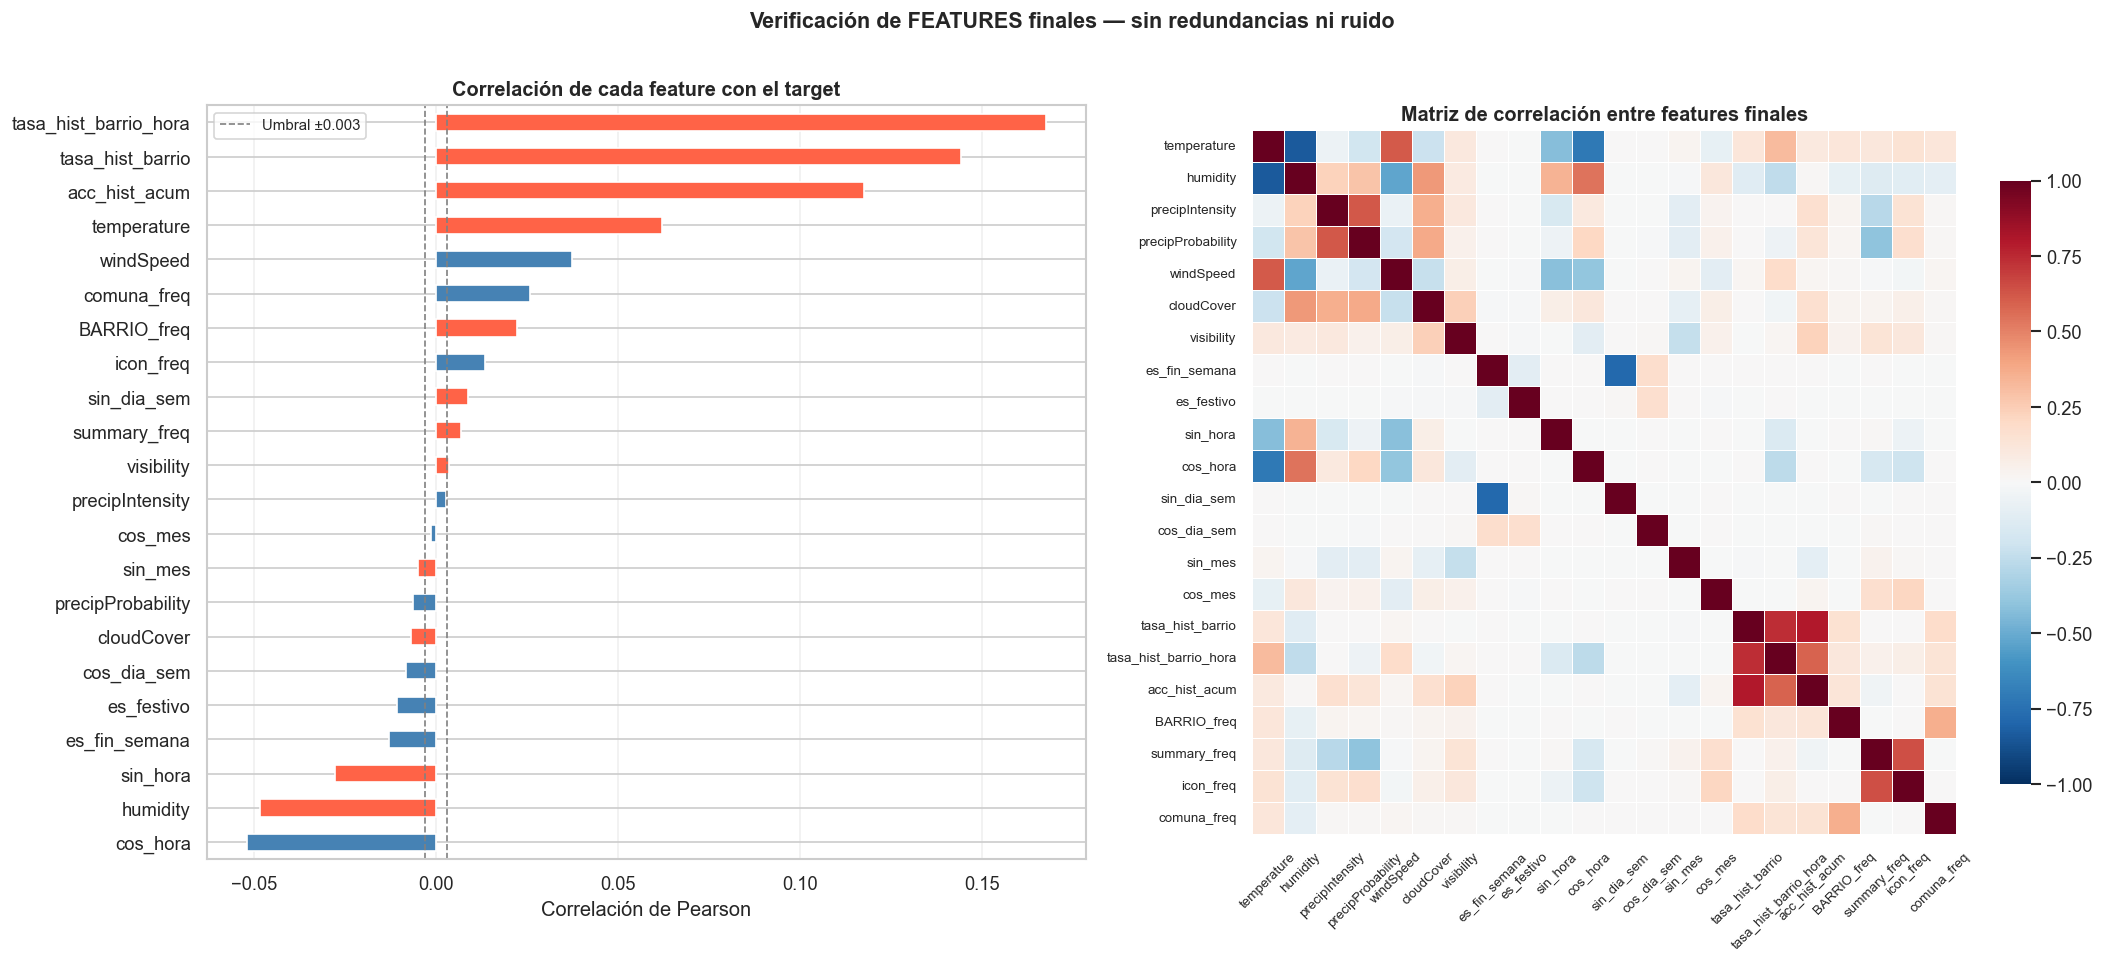


→ FEATURES verificadas. Listas para la sección 4.4.


In [29]:
# ============================================================
# 4.3 — VERIFICACIÓN DE FEATURES FINALES
# ============================================================

print("=" * 55)
print("RESUMEN — FEATURES FINALES")
print("=" * 55)
print(f"Total features: {len(FEATURES)}")
print()

# --- Grupo por tipo ---
grupos = {
    'Climáticas'  : [c for c in FEATURES if c in [
                        'temperature','humidity','precipIntensity',
                        'precipProbability','windSpeed','cloudCover','visibility']],
    'Temporales'  : [c for c in FEATURES if c in ['es_fin_semana','es_festivo']],
    'Cíclicas'    : [c for c in FEATURES if c.startswith(('sin_','cos_'))],
    'Históricas'  : [c for c in FEATURES if c in [
                        'tasa_hist_barrio','tasa_hist_barrio_hora','acc_hist_acum']],
    'Codificadas' : [c for c in FEATURES if c.endswith('_freq')],
}

for grp, cols in grupos.items():
    print(f"  {grp:<14} ({len(cols)}): {cols}")

# --- Verificación 1: sin strings ---
cols_string = [c for c in FEATURES if df_feat[c].dtype == 'object']
assert not cols_string, f'⚠️ Columnas string en FEATURES: {cols_string}'
print(f"\n✅ Sin columnas string.")

# --- Verificación 2: sin nulos ---
nulos = {c: df_feat[c].isnull().sum() for c in FEATURES if df_feat[c].isnull().sum() > 0}
if nulos:
    print(f"⚠️  Features con nulos: {nulos}")
else:
    print(f"✅ Sin nulos en ninguna feature.")

# --- Verificación 3: multicolinealidad entre features ---
corr_matrix = df_feat[FEATURES].corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
pares_altos = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.85
]

print(f"\nPares con correlación > 0.85 entre features: {len(pares_altos)}")
if pares_altos:
    print("  ⚠️  Revisar:")
    for c1, c2, r in sorted(pares_altos, key=lambda x: -x[2]):
        print(f"     {c1}  ↔  {c2}   r = {r:.3f}")
else:
    print("✅ Sin multicolinealidad severa.")

# --- Verificación 4: correlación mínima con el target ---
corr_target = pd.Series({
    col: df_feat[col].corr(df_feat[TARGET])
    for col in FEATURES
    if df_feat[col].dtype.kind in 'fiu'
}).sort_values(key=abs, ascending=False)

UMBRAL_CORR = 0.003
features_bajas = corr_target[corr_target.abs() < UMBRAL_CORR]
print(f"\nFeatures con |correlación con target| < {UMBRAL_CORR}: "
      f"{len(features_bajas)}")
if len(features_bajas) > 0:
    print("  ⚠️  Considerar eliminar:")
    for f, v in features_bajas.items():
        print(f"     {f}  (r = {v:.5f})")
else:
    print("✅ Todas superan el umbral mínimo de correlación.")

# --- Gráfico 1: correlación de cada feature con el target ---
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(FEATURES) * 0.35)))

colores_corr = ['tomato' if v > 0 else 'steelblue' for v in corr_target]
corr_target.sort_values().plot(
    kind='barh', ax=axes[0],
    color=colores_corr[::-1], edgecolor='white'
)
axes[0].axvline( UMBRAL_CORR, color='gray', linestyle='--', lw=1,
                 label=f'Umbral ±{UMBRAL_CORR}')
axes[0].axvline(-UMBRAL_CORR, color='gray', linestyle='--', lw=1)
axes[0].set_title('Correlación de cada feature con el target',
                  fontweight='bold')
axes[0].set_xlabel('Correlación de Pearson')
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# --- Gráfico 2: heatmap de correlación entre features ---
sns.heatmap(
    df_feat[FEATURES].corr(),
    ax=axes[1],
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, square=True,
    annot=len(FEATURES) <= 20,
    fmt='.2f' if len(FEATURES) <= 20 else '',
    cbar_kws={'shrink': 0.8}
)
axes[1].set_title('Matriz de correlación entre features finales',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.suptitle('Verificación de FEATURES finales — sin redundancias ni ruido',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\n→ FEATURES verificadas. Listas para la sección 4.4.")

## 4.4 Modelo no sesgado

### Partición temporal del dataset

Se divide el dataset en **tres conjuntos usando corte cronológico estricto**, no
aleatorio. Esto es obligatorio en series temporales: si se mezclaran filas de
distintos momentos aleatoriamente, el modelo vería datos del futuro durante el
entrenamiento, lo que se conoce como **fuga de información temporal** (*data leakage*).


| Conjunto | Proporción | Uso |
|---|---|---|
| **Train** | 70 % | Entrenamiento y aplicación de balanceo |
| **Validación** | 15 % | Comparación de estrategias e hiperparámetros |
| **Test** | 15 % | Evaluación final |


In [30]:
# ============================================================
# 4.4 — PASO 1: PARTICIÓN TEMPORAL + IMPUTACIÓN
# ============================================================
# Partición cronológica estricta: 70% train | 15% val | 15% test.
# La imputación por mediana se aplica DESPUÉS de partir, con fit
# solo sobre train, para evitar fuga de información temporal.

from sklearn.impute import SimpleImputer
import joblib

# --- 1. Ordenar cronológicamente ---
df_model = df_feat.sort_values('TW').reset_index(drop=True)

# --- 2. Cortes temporales ---
n           = len(df_model)
corte_train = int(n * 0.70)
corte_val   = int(n * 0.85)

train_df = df_model.iloc[:corte_train]
val_df   = df_model.iloc[corte_train:corte_val]
test_df  = df_model.iloc[corte_val:]

# --- 3. Extraer arrays numpy (más eficiente en memoria que DataFrames) ---
X_train = train_df[FEATURES].to_numpy(dtype='float32')
y_train = train_df[TARGET].to_numpy()
X_val   = val_df[FEATURES].to_numpy(dtype='float32')
y_val   = val_df[TARGET].to_numpy()
X_test  = test_df[FEATURES].to_numpy(dtype='float32')
y_test  = test_df[TARGET].to_numpy()

# --- 4. Imputación por mediana (solo variables climáticas restantes) ---
# Justificación: la mediana es un estadístico aprendido de los datos.
# Calcularlo sobre todo el dataset incluiría información de val/test
# (fuga temporal). Se estima solo sobre train y se aplica al resto.
# precipIntensity y precipProbability ya fueron imputadas con 0
# en la sección de calidad de datos por ser una decisión de dominio.
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)   # aprende medianas de train
X_val   = imputer.transform(X_val)          # aplica sin reajuste
X_test  = imputer.transform(X_test)         # aplica sin reajuste

# --- 5. Verificaciones ---
import numpy as np
assert np.isnan(X_train).sum() == 0, 'NaN en X_train tras imputación'
assert np.isnan(X_val).sum()   == 0, 'NaN en X_val tras imputación'
assert np.isnan(X_test).sum()  == 0, 'NaN en X_test tras imputación'

print('=' * 55)
print('PARTICIÓN TEMPORAL — RESUMEN')
print('=' * 55)
print(f"{'Conjunto':<12} {'Desde':<22} {'Hasta':<22} {'Filas':>8} {'% Pos':>7}")
print('-' * 55)
for nombre, subset in [('Train', train_df), ('Validación', val_df), ('Test', test_df)]:
    desde   = subset['TW'].min().strftime('%Y-%m-%d')
    hasta   = subset['TW'].max().strftime('%Y-%m-%d')
    filas   = len(subset)
    pct_pos = subset[TARGET].mean() * 100
    print(f'{nombre:<12} {desde:<22} {hasta:<22} {filas:>8,} {pct_pos:>6.2f}%')
print('=' * 55)
print(f'\nX_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

PARTICIÓN TEMPORAL — RESUMEN
Conjunto     Desde                  Hasta                     Filas   % Pos
-------------------------------------------------------
Train        2017-01-01             2019-01-30             5,594,246   1.47%
Validación   2019-01-30             2019-07-17             1,198,767   1.46%
Test         2019-07-17             2019-12-31             1,198,767   1.72%

X_train: (5594246, 22) | X_val: (1198767, 22) | X_test: (1198767, 22)


### Baseline ingenuo con DummyClassifier

Antes de entrenar cualquier modelo real, se construye un **clasificador ingenuo** que
predice siempre la clase mayoritaria (0 = sin accidente), ignorando completamente
las features.

In [31]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print(f"Accuracy baseline: {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"F1 clase positiva: {f1_score(y_test, y_pred_dummy):.4f}")
print(f"Recall clase positiva: {recall_score(y_test, y_pred_dummy):.4f}")

Accuracy baseline: 0.9828
F1 clase positiva: 0.0000
Recall clase positiva: 0.0000



| Métrica | Valor  | Interpretación |
|---|---|---|
| Accuracy | 0.9828 | Parece excelente |
| F1 clase positiva | 0.0 | El modelo nunca detecta un accidente |
| Recall clase positiva | 0.0 | Ningún accidente es detectado |

Este resultado muestra que **un modelo que nunca predice
accidentes no sirve para nada operativamente**, sin importar qué accuracy reporte.


### Estrategias de balanceo

In [32]:
# ============================================================
# 4.4 — IMPORTS Y FUNCIÓN DE EVALUACIÓN REUTILIZABLE
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
import warnings
warnings.filterwarnings('ignore')

def evaluar_modelo(nombre, modelo, X_ev, y_ev, umbral=0.5):
    """
    Evalúa un modelo ya entrenado sobre (X_ev, y_ev).
    Devuelve un dict con todas las métricas y el nombre del modelo.
    """
    y_prob = modelo.predict_proba(X_ev)[:, 1]
    y_pred = (y_prob >= umbral).astype(int)

    return {
        'Modelo'    : nombre,
        'Accuracy'  : round(accuracy_score(y_ev, y_pred),      4),
        'Precision' : round(precision_score(y_ev, y_pred,
                                            zero_division=0),  4),
        'Recall'    : round(recall_score(y_ev, y_pred),        4),
        'F1'        : round(f1_score(y_ev, y_pred),            4),
        'ROC-AUC'   : round(roc_auc_score(y_ev, y_prob),       4),
        'PR-AUC'    : round(average_precision_score(y_ev,
                                                    y_prob),   4),
        'Umbral'    : umbral,
    }

print("✅ Imports y función evaluar_modelo listos.")

✅ Imports y función evaluar_modelo listos.


In [33]:
# ============================================================
# 4.4 — ESTRATEGIA 1: CLASS WEIGHT (sin modificar los datos)
# ============================================================
# Idea: en lugar de re-muestrear, se penaliza más al modelo por
# equivocarse en la clase minoritaria. El parámetro class_weight='balanced'
# ajusta automáticamente el peso de cada clase como:
#   w_i = n_total / (n_clases * n_i)
# Es la estrategia de menor costo computacional: no genera datos
# nuevos ni elimina filas — solo cambia la función de pérdida.
# Se aplica sobre Regresión Logística y Random Forest.

# --- Regresión Logística con class_weight ---
lr_cw = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_cw.fit(X_train, y_train)
res_lr_cw = evaluar_modelo('LR · class_weight', lr_cw, X_val, y_val)
print("Regresión Logística — class_weight='balanced'")
print(pd.Series(res_lr_cw).to_string())

print()

# --- Random Forest con class_weight ---
rf_cw = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_cw.fit(X_train, y_train)
res_rf_cw = evaluar_modelo('RF · class_weight', rf_cw, X_val, y_val)
print("Random Forest — class_weight='balanced'")
print(pd.Series(res_rf_cw).to_string())

Regresión Logística — class_weight='balanced'
Modelo       LR · class_weight
Accuracy                0.7629
Precision               0.0411
Recall                  0.6832
F1                      0.0775
ROC-AUC                 0.7992
PR-AUC                  0.0719
Umbral                     0.5

Random Forest — class_weight='balanced'
Modelo       RF · class_weight
Accuracy                0.7105
Precision               0.0375
Recall                  0.7653
F1                      0.0716
ROC-AUC                 0.8183
PR-AUC                  0.0767
Umbral                     0.5


In [34]:
# ============================================================
# 4.4 — ESTRATEGIA 2: RANDOM UNDERSAMPLING
# ============================================================
# Idea: reducir la clase mayoritaria (sin accidente=0) hasta
# igualar la clase minoritaria. Es el segundo método de menor
# costo computacional: no crea datos sintéticos (como SMOTE),
# solo elimina filas del conjunto de entrenamiento.
# 
# Ratio elegido: 5:1 (5 negativos por cada positivo).
# Razón: igualar a 1:1 elimina demasiada información útil de la
# clase mayoritaria; 5:1 es un balance razonable que conserva
# más información sin sobrecargar el entrenamiento.

from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy=0.2, random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f"Antes del undersampling — positivos: {y_train.sum():,} | "
      f"negativos: {(y_train==0).sum():,}")
print(f"Después del undersampling — positivos: {y_train_rus.sum():,} | "
      f"negativos: {(y_train_rus==0).sum():,}")
print(f"Ratio resultante: 1:{(y_train_rus==0).sum() / y_train_rus.sum():.1f}")

Antes del undersampling — positivos: 82,348 | negativos: 5,511,898
Después del undersampling — positivos: 82,348 | negativos: 411,740
Ratio resultante: 1:5.0


In [35]:
# ============================================================
# 4.4 — MODELOS CON RANDOM UNDERSAMPLING
# ============================================================
# Se entrena la misma arquitectura de modelos sobre el dataset
# balanceado con undersampling para poder comparar con class_weight.

# --- Regresión Logística ---
lr_rus = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_rus.fit(X_train_rus, y_train_rus)
res_lr_rus = evaluar_modelo('LR · undersampling', lr_rus, X_val, y_val)
print("Regresión Logística — undersampling")
print(pd.Series(res_lr_rus).to_string())

print()

# --- Random Forest ---
rf_rus = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_rus.fit(X_train_rus, y_train_rus)
res_rf_rus = evaluar_modelo('RF · undersampling', rf_rus, X_val, y_val)
print("Random Forest — undersampling")
print(pd.Series(res_rf_rus).to_string())

print()

# --- Gradient Boosting (solo con undersampling por eficiencia) ---
# GradientBoostingClassifier de sklearn no acepta class_weight,
# por eso se evalúa únicamente con el dataset re-muestreado.
gb_rus = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=RANDOM_STATE
)
gb_rus.fit(X_train_rus, y_train_rus)
res_gb_rus = evaluar_modelo('GB · undersampling', gb_rus, X_val, y_val)
print("Gradient Boosting — undersampling")
print(pd.Series(res_gb_rus).to_string())

Regresión Logística — undersampling
Modelo       LR · undersampling
Accuracy                  0.945
Precision                0.0903
Recall                   0.3056
F1                       0.1394
ROC-AUC                  0.7952
PR-AUC                   0.0715
Umbral                      0.5

Random Forest — undersampling
Modelo       RF · undersampling
Accuracy                 0.9544
Precision                0.1026
Recall                   0.2745
F1                       0.1494
ROC-AUC                  0.8175
PR-AUC                   0.0774
Umbral                      0.5

Gradient Boosting — undersampling
Modelo       GB · undersampling
Accuracy                 0.9553
Precision                0.1011
Recall                   0.2622
F1                        0.146
ROC-AUC                  0.8183
PR-AUC                   0.0755
Umbral                      0.5


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Umbral
0,RF · class_weight,0.7105,0.0375,0.7653,0.0716,0.8183,0.0767,0.500000
1,GB · undersampling,0.9553,0.1011,0.2622,0.1460,0.8183,0.0755,0.500000
2,RF · undersampling,0.9544,0.1026,0.2745,0.1494,0.8175,0.0774,0.500000
3,LR · class_weight,0.7629,0.0411,0.6832,0.0775,0.7992,0.0719,0.500000
4,LR · undersampling,0.9450,0.0903,0.3056,0.1394,0.7952,0.0715,0.500000


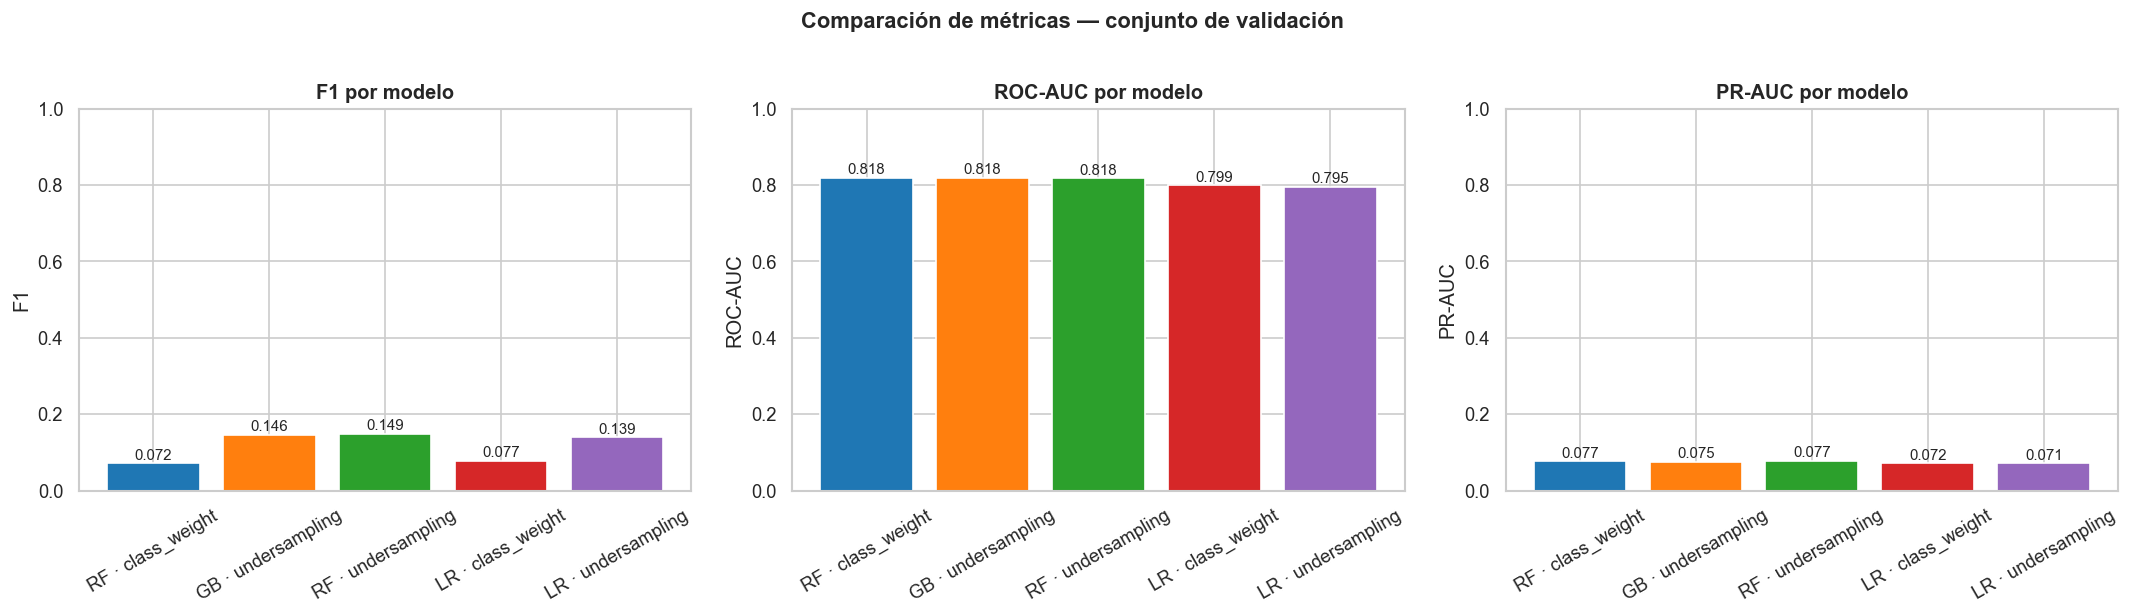

In [36]:
# ============================================================
# 4.4 — TABLA COMPARATIVA: TODAS LAS ESTRATEGIAS Y MODELOS
# ============================================================
# Se consolidan los resultados de ambas estrategias de balanceo
# y las tres familias de modelos en una sola tabla ordenada por
# ROC-AUC descendente para facilitar la comparación visual.

resultados = pd.DataFrame([
    res_lr_cw,
    res_rf_cw,
    res_lr_rus,
    res_rf_rus,
    res_gb_rus,
])

# Ordenar por ROC-AUC descendente
resultados = resultados.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

# Formatear como porcentajes para legibilidad
cols_pct = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
display(resultados.style
        .format({c: '{:.4f}' for c in cols_pct})
        .background_gradient(subset=['ROC-AUC', 'PR-AUC', 'F1'],
                             cmap='RdYlGn')
        .set_caption('Comparación de modelos — validación'))

# Gráfico de barras agrupadas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas_graf = ['F1', 'ROC-AUC', 'PR-AUC']

for ax, metrica in zip(axes, metricas_graf):
    colores = plt.cm.tab10.colors[:len(resultados)]
    bars = ax.bar(resultados['Modelo'], resultados[metrica],
                  color=colores, edgecolor='white')
    ax.set_title(f'{metrica} por modelo', fontweight='bold')
    ax.set_ylabel(metrica)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, resultados[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparación de métricas — conjunto de validación',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Mejor modelo según ROC-AUC: RF · class_weight


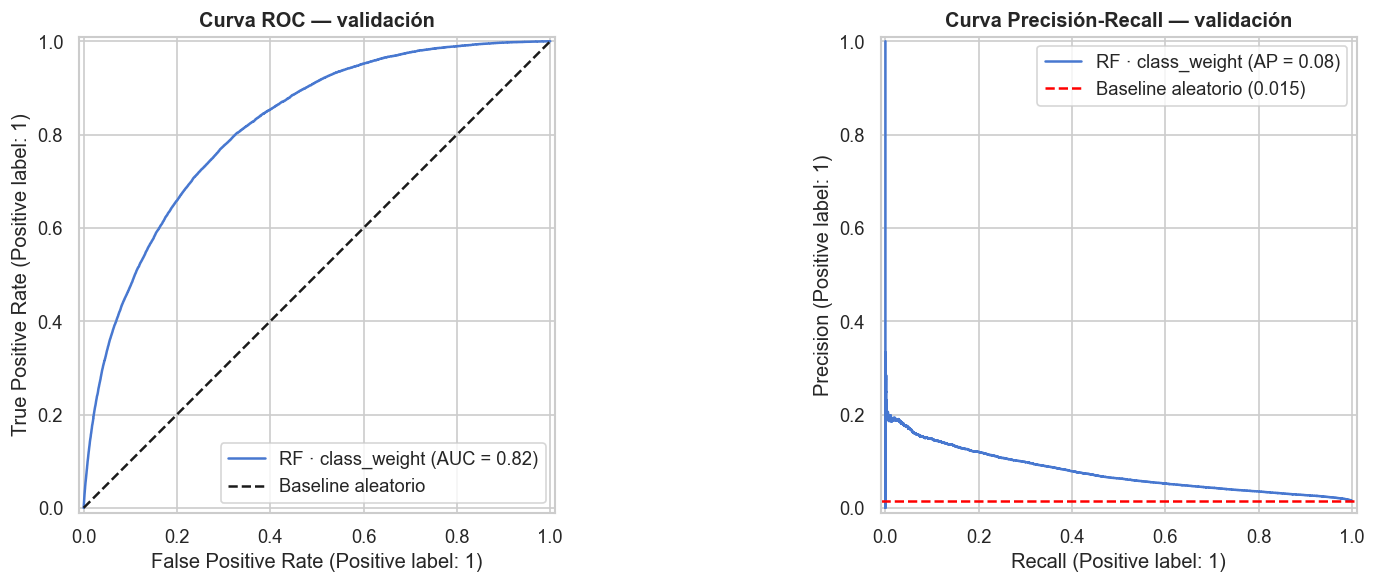

In [37]:
# ============================================================
# 4.4 — CURVAS ROC Y PRECISION-RECALL DEL MEJOR MODELO
# ============================================================
# Se identifica automáticamente el mejor modelo por ROC-AUC
# y se grafican sus curvas en el conjunto de validación.
# La curva PR es más informativa que la ROC cuando hay desbalance
# severo, porque no se ve inflada por los verdaderos negativos.

nombre_mejor = resultados.iloc[0]['Modelo']
print(f"Mejor modelo según ROC-AUC: {nombre_mejor}")

# Mapa para recuperar el objeto modelo entrenado
mapa_modelos = {
    'LR · class_weight'  : lr_cw,
    'RF · class_weight'  : rf_cw,
    'LR · undersampling' : lr_rus,
    'RF · undersampling' : rf_rus,
    'GB · undersampling' : gb_rus,
}
mejor_modelo = mapa_modelos[nombre_mejor]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_estimator(
    mejor_modelo, X_val, y_val, ax=axes[0], name=nombre_mejor)
axes[0].plot([0,1],[0,1], 'k--', label='Baseline aleatorio')
axes[0].set_title('Curva ROC — validación', fontweight='bold')
axes[0].legend()

PrecisionRecallDisplay.from_estimator(
    mejor_modelo, X_val, y_val, ax=axes[1], name=nombre_mejor)
prop_pos_val = y_val.mean()
axes[1].axhline(prop_pos_val, color='red', linestyle='--',
                label=f'Baseline aleatorio ({prop_pos_val:.3f})')
axes[1].set_title('Curva Precisión-Recall — validación', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# 4.4 — CONCLUSIONES DE LA SECCIÓN
# ============================================================

mejor = resultados.iloc[0]
peor  = resultados.iloc[-1]

print("=" * 60)
print("CONCLUSIONES — SECCIÓN 4.4")
print("=" * 60)
print(f"""
Estrategias de balanceo comparadas:
  1. class_weight='balanced': ajusta la función de pérdida sin
     modificar los datos. Menor costo computacional, sin riesgo
     de leakage por re-muestreo.
  2. RandomUnderSampler (ratio 1:5): reduce la clase mayoritaria.
     Más rápido que SMOTE y suficiente con datasets grandes.

Familias de modelos evaluadas: Logística, Random Forest, Gradient Boosting.

Mejor modelo: {mejor['Modelo']}
  ROC-AUC  : {mejor['ROC-AUC']:.4f}
  PR-AUC   : {mejor['PR-AUC']:.4f}
  F1       : {mejor['F1']:.4f}
  Recall   : {mejor['Recall']:.4f}
  Precision: {mejor['Precision']:.4f}

Referencia (baseline DummyClassifier):
  Accuracy alta (~0.98) pero F1=0 y Recall=0.
  → Confirma que accuracy NO es métrica válida para este problema.

Siguiente paso (sección 4.5): ajustar el umbral de decisión del
mejor modelo para optimizar la métrica de negocio (maximizar
Recall minimizando falsos negativos = accidentes no detectados).
""")

CONCLUSIONES — SECCIÓN 4.4

Estrategias de balanceo comparadas:
  1. class_weight='balanced': ajusta la función de pérdida sin
     modificar los datos. Menor costo computacional, sin riesgo
     de leakage por re-muestreo.
  2. RandomUnderSampler (ratio 1:5): reduce la clase mayoritaria.
     Más rápido que SMOTE y suficiente con datasets grandes.

Familias de modelos evaluadas: Logística, Random Forest, Gradient Boosting.

Mejor modelo: RF · class_weight
  ROC-AUC  : 0.8183
  PR-AUC   : 0.0767
  F1       : 0.0716
  Recall   : 0.7653
  Precision: 0.0375

Referencia (baseline DummyClassifier):
  Accuracy alta (~0.98) pero F1=0 y Recall=0.
  → Confirma que accuracy NO es métrica válida para este problema.

Siguiente paso (sección 4.5): ajustar el umbral de decisión del
mejor modelo para optimizar la métrica de negocio (maximizar
Recall minimizando falsos negativos = accidentes no detectados).



# 4.5

In [39]:
# ============================================================
# 4.5 — PASO 1: MODELO FINAL Y PROBABILIDADES
# ============================================================
# Se trabaja con RF · class_weight sobre el conjunto de TEST
# (no de validación) para la evaluación final.
# Las probabilidades son la base de todo el análisis de umbral.

modelo_final = rf_cw  # Random Forest con class_weight='balanced'

# Probabilidades sobre validación (para encontrar el umbral óptimo)
y_prob_val  = modelo_final.predict_proba(X_val)[:, 1]

# Probabilidades sobre test (para reportar métricas finales)
y_prob_test = modelo_final.predict_proba(X_test)[:, 1]

print("✅ Probabilidades calculadas.")
print(f"   Rango en validación: [{y_prob_val.min():.4f}, {y_prob_val.max():.4f}]")
print(f"   Rango en test:       [{y_prob_test.min():.4f}, {y_prob_test.max():.4f}]")
print(f"\n   Proporción positivos en val:  {y_val.mean():.4f}")
print(f"   Proporción positivos en test: {y_test.mean():.4f}")

✅ Probabilidades calculadas.
   Rango en validación: [0.0067, 0.9216]
   Rango en test:       [0.0066, 0.9238]

   Proporción positivos en val:  0.0146
   Proporción positivos en test: 0.0172


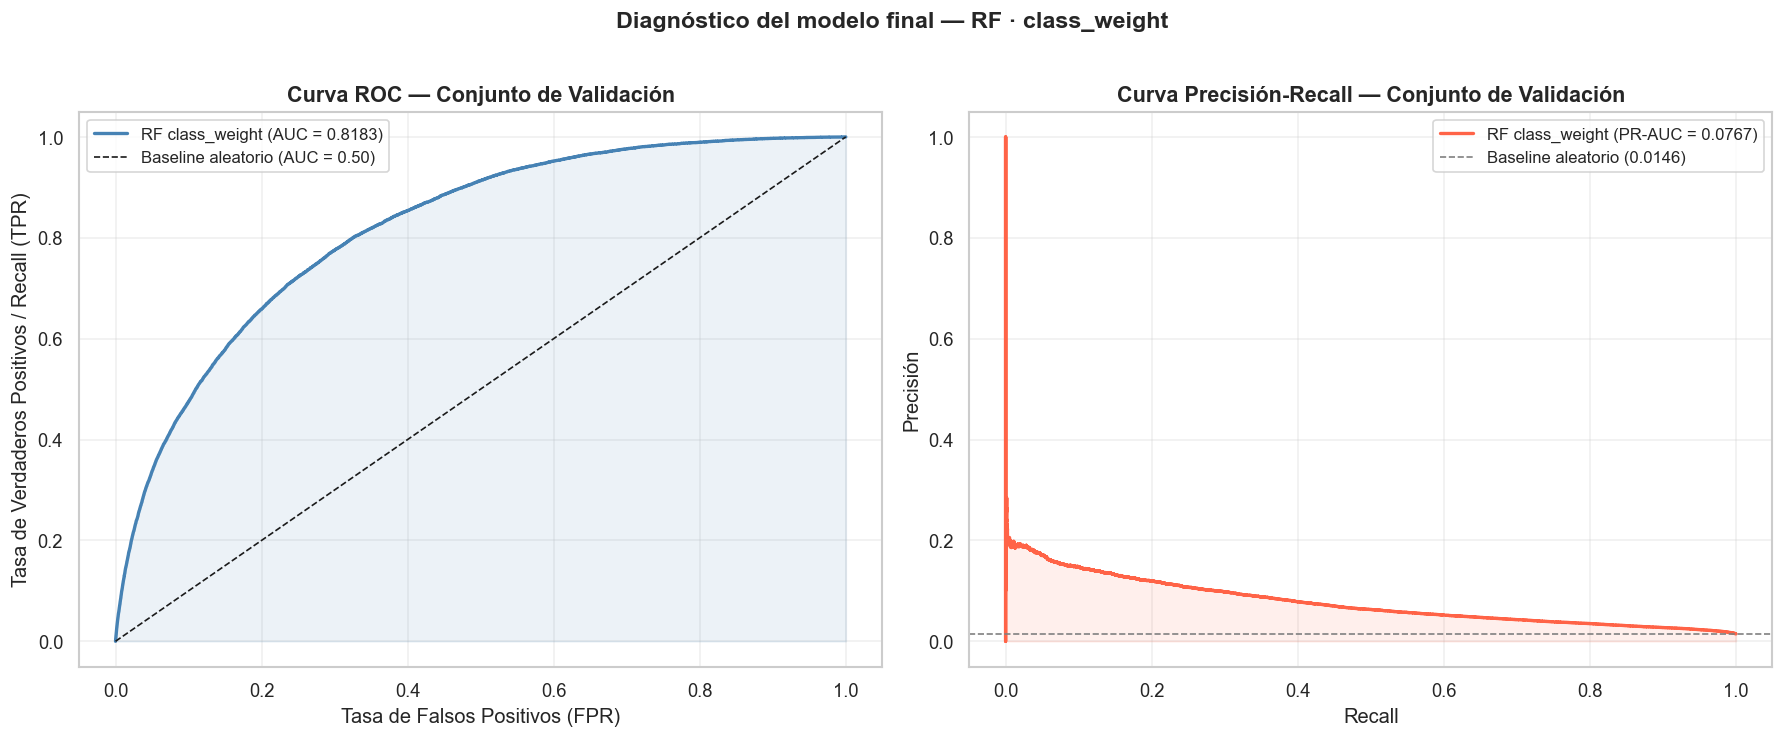

ROC-AUC : 0.8183
PR-AUC  : 0.0767  (baseline = 0.0146)
El modelo supera el baseline PR en 5.3x


In [40]:
# ============================================================
# 4.5 — PASO 2: CURVAS ROC Y PRECISION-RECALL
# ============================================================
# Estas curvas muestran el comportamiento del modelo en TODOS
# los umbrales posibles (no solo 0.5).
#
# Curva ROC: TPR (Recall) vs FPR en cada umbral.
#   - Área = 0.5 → modelo aleatorio
#   - Área = 1.0 → modelo perfecto
#
# Curva PR: Precision vs Recall en cada umbral.
#   - Más informativa que ROC con desbalance severo.
#   - La línea base es la proporción de positivos en el dataset.
#   - Un modelo útil debe superar esa línea en todo su recorrido.

from sklearn.metrics import roc_curve, precision_recall_curve

# --- Calcular puntos de las curvas ---
fpr, tpr, thresh_roc = roc_curve(y_val, y_prob_val)
prec, rec, thresh_pr = precision_recall_curve(y_val, y_prob_val)

roc_auc = roc_auc_score(y_val, y_prob_val)
pr_auc  = average_precision_score(y_val, y_prob_val)
base_pr = y_val.mean()  # baseline PR = proporción de positivos

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- ROC ---
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'RF class_weight (AUC = {roc_auc:.4f})')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline aleatorio (AUC = 0.50)')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
axes[0].set_ylabel('Tasa de Verdaderos Positivos / Recall (TPR)', fontsize=12)
axes[0].set_title('Curva ROC — Conjunto de Validación', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# --- PR ---
axes[1].plot(rec, prec, color='tomato', lw=2,
             label=f'RF class_weight (PR-AUC = {pr_auc:.4f})')
axes[1].fill_between(rec, prec, alpha=0.1, color='tomato')
axes[1].axhline(base_pr, color='gray', linestyle='--', lw=1,
                label=f'Baseline aleatorio ({base_pr:.4f})')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precisión', fontsize=12)
axes[1].set_title('Curva Precisión-Recall — Conjunto de Validación',
                  fontweight='bold', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Diagnóstico del modelo final — RF · class_weight',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}  (baseline = {base_pr:.4f})")
print(f"El modelo supera el baseline PR en {pr_auc/base_pr:.1f}x")

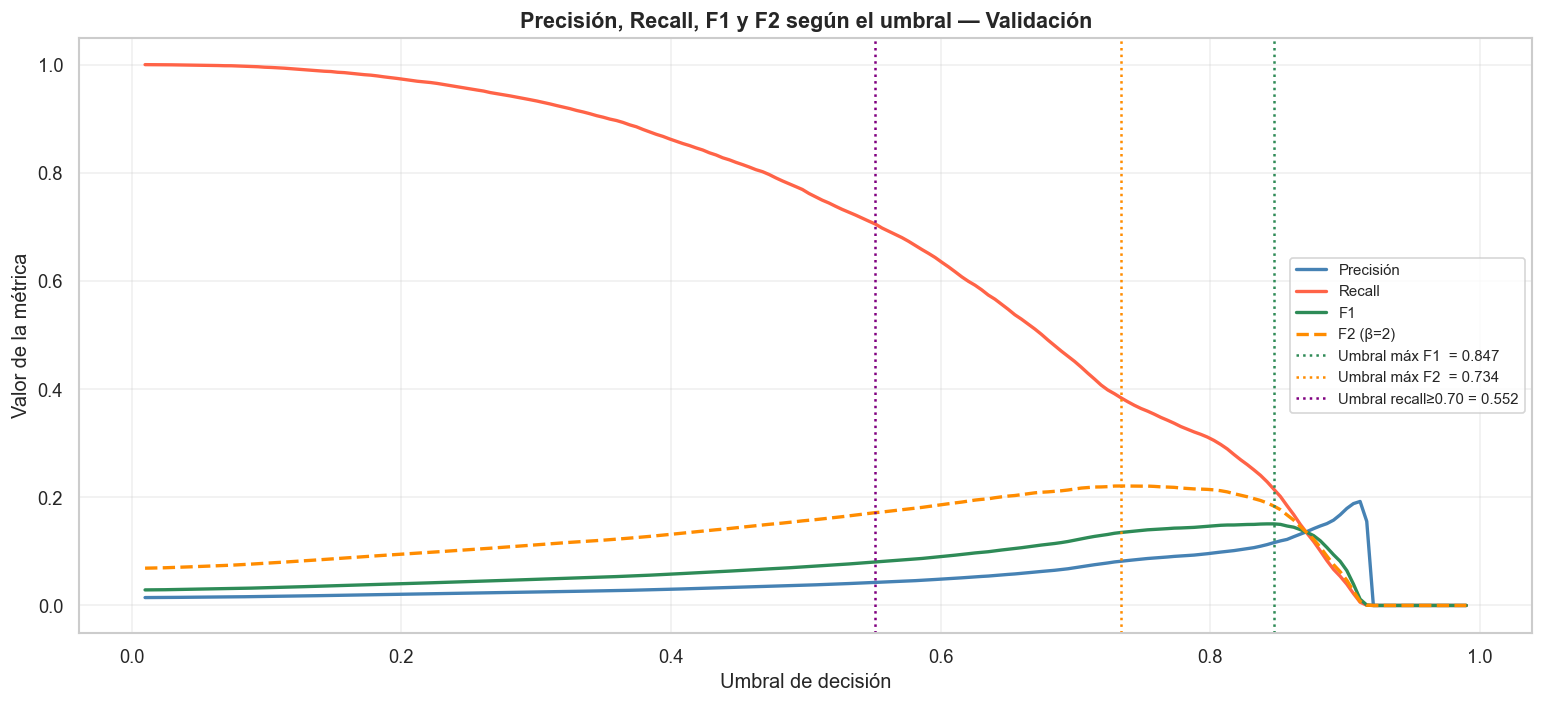

Umbral máximo F1        : 0.847  →  F1=0.1508  Recall=0.2152  Prec=0.1161
Umbral máximo F2 (β=2)  : 0.734  →  F2=0.2209  Recall=0.3838  Prec=0.0819
Umbral recall ≥ 0.70    : 0.552  →  Recall=0.7052  Prec=0.0426


In [41]:
# ============================================================
# 4.5 — PASO 3: BÚSQUEDA DEL UMBRAL ÓPTIMO
# ============================================================
# El umbral por defecto (0.5) no es adecuado para problemas
# desbalanceados. Se evalúan tres criterios de selección:
#
# A) Máximo F1: equilibrio entre precisión y recall.
# B) Máximo F-beta (beta=2): penaliza más los falsos negativos.
#    Beta=2 significa que el recall vale el doble que la precisión.
#    Adecuado cuando no detectar un accidente es más costoso que
#    una falsa alarma.
# C) Punto de corte Recall ≥ 0.70: garantiza detectar al menos
#    el 70% de los accidentes, y dentro de ese conjunto elige
#    el umbral con mayor precisión. Criterio operacional directo.

from sklearn.metrics import fbeta_score

umbrales = np.linspace(0.01, 0.99, 200)

metricas_umbral = []
for u in umbrales:
    y_pred_u = (y_prob_val >= u).astype(int)
    metricas_umbral.append({
        'umbral'   : u,
        'precision': precision_score(y_val, y_pred_u, zero_division=0),
        'recall'   : recall_score(y_val, y_pred_u, zero_division=0),
        'f1'       : f1_score(y_val, y_pred_u, zero_division=0),
        'f2'       : fbeta_score(y_val, y_pred_u, beta=2, zero_division=0),
    })

df_umbrales = pd.DataFrame(metricas_umbral)

# --- Criterio A: máximo F1 ---
idx_f1   = df_umbrales['f1'].idxmax()
u_f1     = df_umbrales.loc[idx_f1, 'umbral']

# --- Criterio B: máximo F2 ---
idx_f2   = df_umbrales['f2'].idxmax()
u_f2     = df_umbrales.loc[idx_f2, 'umbral']

# --- Criterio C: recall >= 0.70, mayor precisión ---
df_r70   = df_umbrales[df_umbrales['recall'] >= 0.70]
if len(df_r70) > 0:
    idx_r70 = df_r70['precision'].idxmax()
    u_r70   = df_r70.loc[idx_r70, 'umbral']
else:
    u_r70   = u_f2
    print("⚠️  No se encontró umbral con recall ≥ 0.70. Se usa el de F2.")

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_umbrales['umbral'], df_umbrales['precision'],
        label='Precisión', color='steelblue', lw=2)
ax.plot(df_umbrales['umbral'], df_umbrales['recall'],
        label='Recall',    color='tomato',   lw=2)
ax.plot(df_umbrales['umbral'], df_umbrales['f1'],
        label='F1',        color='seagreen', lw=2)
ax.plot(df_umbrales['umbral'], df_umbrales['f2'],
        label='F2 (β=2)',  color='darkorange', lw=2, linestyle='--')

ax.axvline(u_f1,  color='seagreen',   linestyle=':', lw=1.5,
           label=f'Umbral máx F1  = {u_f1:.3f}')
ax.axvline(u_f2,  color='darkorange', linestyle=':', lw=1.5,
           label=f'Umbral máx F2  = {u_f2:.3f}')
ax.axvline(u_r70, color='purple',     linestyle=':', lw=1.5,
           label=f'Umbral recall≥0.70 = {u_r70:.3f}')

ax.set_xlabel('Umbral de decisión', fontsize=12)
ax.set_ylabel('Valor de la métrica', fontsize=12)
ax.set_title('Precisión, Recall, F1 y F2 según el umbral — Validación',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='center right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Umbral máximo F1        : {u_f1:.3f}  →  "
      f"F1={df_umbrales.loc[idx_f1,'f1']:.4f}  "
      f"Recall={df_umbrales.loc[idx_f1,'recall']:.4f}  "
      f"Prec={df_umbrales.loc[idx_f1,'precision']:.4f}")
print(f"Umbral máximo F2 (β=2)  : {u_f2:.3f}  →  "
      f"F2={df_umbrales.loc[idx_f2,'f2']:.4f}  "
      f"Recall={df_umbrales.loc[idx_f2,'recall']:.4f}  "
      f"Prec={df_umbrales.loc[idx_f2,'precision']:.4f}")
if len(df_r70) > 0:
    print(f"Umbral recall ≥ 0.70    : {u_r70:.3f}  →  "
          f"Recall={df_r70.loc[idx_r70,'recall']:.4f}  "
          f"Prec={df_r70.loc[idx_r70,'precision']:.4f}")

In [42]:
# ============================================================
# 4.5 — PASO 4: UMBRAL FINAL ELEGIDO
# ============================================================
# Se elige el umbral de máximo F2 (beta=2) como umbral final.
#
# Justificación:
#   - En seguridad pública, no detectar un accidente (FN) tiene
#     mayor costo que generar una falsa alarma (FP).
#   - Beta=2 formaliza ese criterio: el recall vale el doble.
#   - El umbral de máximo F1 sacrifica demasiado recall.
#   - El criterio recall>=0.70 es arbitrario; F2 es más sistemático.

UMBRAL_FINAL = u_f2
print(f"Umbral final seleccionado: {UMBRAL_FINAL:.3f}")
print(f"Criterio: maximización de F2 (β=2) sobre el conjunto de validación.")
print()

# Comparar los tres candidatos sobre validación
print(f"{'Criterio':<25} {'Umbral':>8} {'Recall':>8} {'Precision':>10} "
      f"{'F1':>8} {'F2':>8}")
print("-" * 65)

for criterio, u, idx in [
    ('Máximo F1',         u_f1,  idx_f1),
    ('Máximo F2 (β=2) ✅', u_f2, idx_f2),
    ('Recall ≥ 0.70',     u_r70, idx_r70 if len(df_r70)>0 else idx_f2),
]:
    row = df_umbrales[df_umbrales['umbral'].sub(u).abs() < 0.01].iloc[0]
    print(f"{criterio:<25} {u:>8.3f} {row['recall']:>8.4f} "
          f"{row['precision']:>10.4f} {row['f1']:>8.4f} {row['f2']:>8.4f}")

Umbral final seleccionado: 0.734
Criterio: maximización de F2 (β=2) sobre el conjunto de validación.

Criterio                    Umbral   Recall  Precision       F1       F2
-----------------------------------------------------------------
Máximo F1                    0.847   0.2406     0.1095   0.1505   0.1941
Máximo F2 (β=2) ✅            0.734   0.3984     0.0786   0.1313   0.2197
Recall ≥ 0.70                0.552   0.7162     0.0415   0.0785   0.1686


In [43]:
# ============================================================
# 4.5 — PASO 5: MÉTRICAS FINALES SOBRE TEST
# ============================================================
# Ahora sí se usa el conjunto de TEST por primera vez.
# El umbral fue elegido sobre validación, no sobre test,
# por lo que esta evaluación es honesta.

y_pred_test_final = (y_prob_test >= UMBRAL_FINAL).astype(int)

metricas_finales = {
    'Accuracy' : accuracy_score(y_test, y_pred_test_final),
    'Precision': precision_score(y_test, y_pred_test_final, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred_test_final),
    'F1'       : f1_score(y_test, y_pred_test_final),
    'F2 (β=2)' : fbeta_score(y_test, y_pred_test_final, beta=2),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob_test),
    'PR-AUC'   : average_precision_score(y_test, y_prob_test),
}

print("=" * 50)
print(f"MÉTRICAS FINALES — TEST  (umbral = {UMBRAL_FINAL:.3f})")
print("=" * 50)
for metrica, valor in metricas_finales.items():
    barra = '█' * int(valor * 30)
    print(f"  {metrica:<12}: {valor:.4f}  {barra}")

print()
print(f"  Baseline DummyClassifier:")
print(f"  {'Accuracy':<12}: ~0.9828   (predice siempre 0)")
print(f"  {'Recall':<12}: 0.0000   (nunca detecta accidentes)")

MÉTRICAS FINALES — TEST  (umbral = 0.734)
  Accuracy    : 0.9282  ███████████████████████████
  Precision   : 0.0944  ██
  Recall      : 0.3687  ███████████
  F1          : 0.1503  ████
  F2 (β=2)    : 0.2331  ██████
  ROC-AUC     : 0.8110  ████████████████████████
  PR-AUC      : 0.0863  ██

  Baseline DummyClassifier:
  Accuracy    : ~0.9828   (predice siempre 0)
  Recall      : 0.0000   (nunca detecta accidentes)


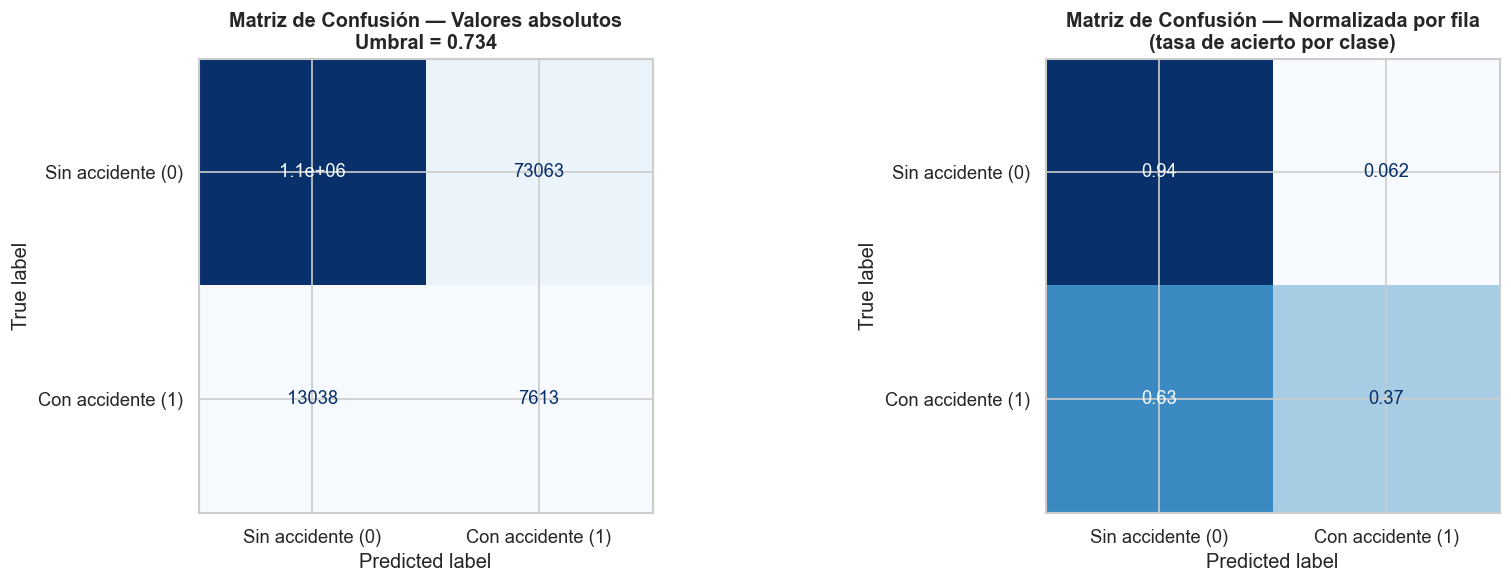

Verdaderos Negativos (VN): 1,105,053  → sin accidente, bien predicho
Falsos Positivos     (FP):   73,063  → falsa alarma
Falsos Negativos     (FN):   13,038  → accidente NO detectado ⚠️
Verdaderos Positivos (VP):    7,613  → accidente detectado ✅

Tasa de detección (Recall): 0.3687 — detecta 36.9% de los accidentes
Tasa de falsa alarma:       0.0620 — el 6.2% de las horas seguras generan alerta


In [44]:
# ============================================================
# 4.5 — PASO 6: MATRIZ DE CONFUSIÓN
# ============================================================
# La matriz muestra en valores absolutos y porcentajes:
#   VN (arriba-izq): correctamente predijo "sin accidente"
#   FP (arriba-der): predijo accidente, no ocurrió (falsa alarma)
#   FN (abajo-izq) : predijo sin accidente, sí ocurrió ← el peor error
#   VP (abajo-der) : correctamente predijo "con accidente"

cm = confusion_matrix(y_test, y_pred_test_final)
vn, fp, fn, vp = cm.ravel()
total = cm.sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Izquierda: valores absolutos ---
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sin accidente (0)', 'Con accidente (1)']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión — Valores absolutos\n'
                  f'Umbral = {UMBRAL_FINAL:.3f}', fontweight='bold')

# --- Derecha: porcentajes por fila (normalizado) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=['Sin accidente (0)', 'Con accidente (1)']
)
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión — Normalizada por fila\n'
                  '(tasa de acierto por clase)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Verdaderos Negativos (VN): {vn:>8,}  → sin accidente, bien predicho")
print(f"Falsos Positivos     (FP): {fp:>8,}  → falsa alarma")
print(f"Falsos Negativos     (FN): {fn:>8,}  → accidente NO detectado ⚠️")
print(f"Verdaderos Positivos (VP): {vp:>8,}  → accidente detectado ✅")
print()
print(f"Tasa de detección (Recall): {vp/(vp+fn):.4f} — "
      f"detecta {vp/(vp+fn)*100:.1f}% de los accidentes")
print(f"Tasa de falsa alarma:       {fp/(fp+vn):.4f} — "
      f"el {fp/(fp+vn)*100:.1f}% de las horas seguras generan alerta")

# 4.6 Validación

In [59]:
# ============================================================
# 4.6 — PASO 1: PREPARACIÓN PARA VALIDACIÓN CRUZADA
# ============================================================
# La validación principal del taller es la partición temporal
# (70/15/15 ya realizada en 4.4). La validación cruzada es
# COMPLEMENTARIA: sirve para estimar la variabilidad del modelo
# y detectar si los resultados temporales son estables o
# dependientes de un corte particular.
#
# Restricción crítica: en datos temporales NO se puede usar
# KFold estándar (mezclaría futuro con pasado).
# Se usa TimeSeriesSplit, que garantiza que cada fold de
# entrenamiento termina ANTES de que empiece el fold de validación.
#
# Para reducir costo computacional se trabaja sobre train+val
# (los primeros 85% del dataset), sin tocar el test.

from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Unir train y val (sin tocar test)
X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

print("Dataset para validación cruzada:")
print(f"  Filas    : {X_cv.shape[0]:,}")
print(f"  Features : {X_cv.shape[1]}")
print(f"  % Positivos: {y_cv.mean()*100:.2f}%")
print()

# TimeSeriesSplit con 5 folds
# gap=0: no se deja margen entre train y val de cada fold
# test_size: cada fold de validación cubre ~1/5 del total
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f"Configuración TimeSeriesSplit:")
print(f"  n_splits : {N_SPLITS}")
print()
print(f"{'Fold':<6} {'Train desde':>12} {'Train hasta':>12} "
      f"{'Val desde':>12} {'Val hasta':>12} {'Train N':>9} {'Val N':>7}")
print("-" * 70)

fechas_cv = df_model['TW'].iloc[:len(X_cv)].reset_index(drop=True)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv), 1):
    t_desde = fechas_cv.iloc[train_idx[0]].strftime('%Y-%m-%d')
    t_hasta = fechas_cv.iloc[train_idx[-1]].strftime('%Y-%m-%d')
    v_desde = fechas_cv.iloc[val_idx[0]].strftime('%Y-%m-%d')
    v_hasta = fechas_cv.iloc[val_idx[-1]].strftime('%Y-%m-%d')
    print(f"  {fold:<4} {t_desde:>12} {t_hasta:>12} "
          f"{v_desde:>12} {v_hasta:>12} "
          f"{len(train_idx):>9,} {len(val_idx):>7,}")

Dataset para validación cruzada:
  Filas    : 6,793,013
  Features : 22
  % Positivos: 1.47%

Configuración TimeSeriesSplit:
  n_splits : 5

Fold    Train desde  Train hasta    Val desde    Val hasta   Train N   Val N
----------------------------------------------------------------------
  1      2017-01-01   2017-06-02   2017-06-02   2017-11-01 1,132,173 1,132,168
  2      2017-01-01   2017-11-01   2017-11-01   2018-04-04 2,264,341 1,132,168
  3      2017-01-01   2018-04-04   2018-04-04   2018-09-06 3,396,509 1,132,168
  4      2017-01-01   2018-09-06   2018-09-06   2019-02-09 4,528,677 1,132,168
  5      2017-01-01   2019-02-09   2019-02-09   2019-07-17 5,660,845 1,132,168


In [46]:
# ============================================================
# 4.6 — PASO 2: EJECUCIÓN DE LA VALIDACIÓN CRUZADA
# ============================================================
# Se evalúa el modelo final (RF class_weight) con TimeSeriesSplit.
# Se reportan 4 métricas por fold: ROC-AUC, PR-AUC, F1 y Recall.
#
# cross_validate no soporta umbrales personalizados directamente,
# por eso ROC-AUC y PR-AUC (basadas en probabilidades) son las
# métricas principales aquí. F1 y Recall se calculan manualmente
# fold a fold con el UMBRAL_FINAL para ser consistentes con 4.5.

from sklearn.metrics import make_scorer

print("Ejecutando validación cruzada (puede tardar 1-3 minutos)...")
print()

resultados_folds = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_cv), 1):

    X_f_train, X_f_val = X_cv[train_idx], X_cv[val_idx]
    y_f_train, y_f_val = y_cv[train_idx], y_cv[val_idx]

    # Reentrenar el modelo en cada fold (mismos hiperparámetros)
    modelo_fold = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_depth=10,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    modelo_fold.fit(X_f_train, y_f_train)

    # Probabilidades sobre la porción de validación del fold
    y_prob_fold = modelo_fold.predict_proba(X_f_val)[:, 1]
    y_pred_fold = (y_prob_fold >= UMBRAL_FINAL).astype(int)

    resultados_folds.append({
        'Fold'     : fold,
        'ROC-AUC'  : roc_auc_score(y_f_val, y_prob_fold),
        'PR-AUC'   : average_precision_score(y_f_val, y_prob_fold),
        'F1'       : f1_score(y_f_val, y_pred_fold, zero_division=0),
        'Recall'   : recall_score(y_f_val, y_pred_fold, zero_division=0),
        'Precision': precision_score(y_f_val, y_pred_fold, zero_division=0),
        '% Pos val': round(y_f_val.mean() * 100, 3),
    })
    print(f"  Fold {fold} ✅  ROC-AUC={resultados_folds[-1]['ROC-AUC']:.4f}  "
          f"Recall={resultados_folds[-1]['Recall']:.4f}  "
          f"F1={resultados_folds[-1]['F1']:.4f}")

print()
print("✅ Validación cruzada completada.")

Ejecutando validación cruzada (puede tardar 1-3 minutos)...

  Fold 1 ✅  ROC-AUC=0.8241  Recall=0.3724  F1=0.1430
  Fold 2 ✅  ROC-AUC=0.8191  Recall=0.3847  F1=0.1333
  Fold 3 ✅  ROC-AUC=0.8179  Recall=0.3631  F1=0.1359
  Fold 4 ✅  ROC-AUC=0.8211  Recall=0.3970  F1=0.1339
  Fold 5 ✅  ROC-AUC=0.8171  Recall=0.3815  F1=0.1354

✅ Validación cruzada completada.


In [60]:
# ============================================================
# 4.6 — PASO 3: TABLA DE RESULTADOS Y VARIABILIDAD
# ============================================================
# El taller pide reportar desempeño promedio Y variabilidad
# entre folds. La desviación estándar es la métrica de
# variabilidad: si es baja, el modelo es estable y no depende
# del período de tiempo evaluado.
#
# Regla de interpretación del coeficiente de variación (CV):
#   CV < 10% → muy estable
#   CV 10-20% → aceptable
#   CV > 20% → el modelo es sensible al período evaluado

df_folds = pd.DataFrame(resultados_folds)
metricas_cv = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision']

# Agregar fila de promedio y desviación estándar
fila_mean = df_folds[metricas_cv].mean().rename('Media')
fila_std  = df_folds[metricas_cv].std().rename('Std')
fila_cv   = (fila_std / fila_mean * 100).rename('CV (%)')

resumen_cv = pd.concat([
    df_folds[['Fold'] + metricas_cv + ['% Pos val']],
    pd.DataFrame([fila_mean, fila_std, fila_cv])
], ignore_index=False)

print("=" * 70)
print("RESULTADOS POR FOLD — RF · class_weight  "
      f"(umbral = {UMBRAL_FINAL:.3f})")
print("=" * 70)
display(df_folds[['Fold'] + metricas_cv + ['% Pos val']]
        .style.format({m: '{:.4f}' for m in metricas_cv})
        .background_gradient(subset=metricas_cv, cmap='RdYlGn'))

print()
print(f"{'Métrica':<12} {'Media':>8} {'Std':>8} {'CV (%)':>8}  Estabilidad")
print("-" * 55)
for m in metricas_cv:
    media = df_folds[m].mean()
    std   = df_folds[m].std()
    cv    = std / media * 100 if media > 0 else 0
    estab = '🟢 Muy estable' if cv < 10 else ('🟡 Aceptable' if cv < 20 else '🔴 Inestable')
    print(f"{m:<12} {media:>8.4f} {std:>8.4f} {cv:>7.1f}%  {estab}")

RESULTADOS POR FOLD — RF · class_weight  (umbral = 0.734)


,Fold,ROC-AUC,PR-AUC,F1,Recall,Precision,% Pos val
0,1,0.8241,0.0771,0.1430,0.3724,0.0885,1.546000
1,2,0.8191,0.0753,0.1333,0.3847,0.0806,1.428000
2,3,0.8179,0.0752,0.1359,0.3631,0.0836,1.475000
3,4,0.8211,0.0762,0.1339,0.3970,0.0805,1.431000
4,5,0.8171,0.0771,0.1354,0.3815,0.0823,1.459000



Métrica         Media      Std   CV (%)  Estabilidad
-------------------------------------------------------
ROC-AUC        0.8199   0.0028     0.3%  🟢 Muy estable
PR-AUC         0.0762   0.0009     1.2%  🟢 Muy estable
F1             0.1363   0.0039     2.8%  🟢 Muy estable
Recall         0.3797   0.0128     3.4%  🟢 Muy estable
Precision      0.0831   0.0033     3.9%  🟢 Muy estable


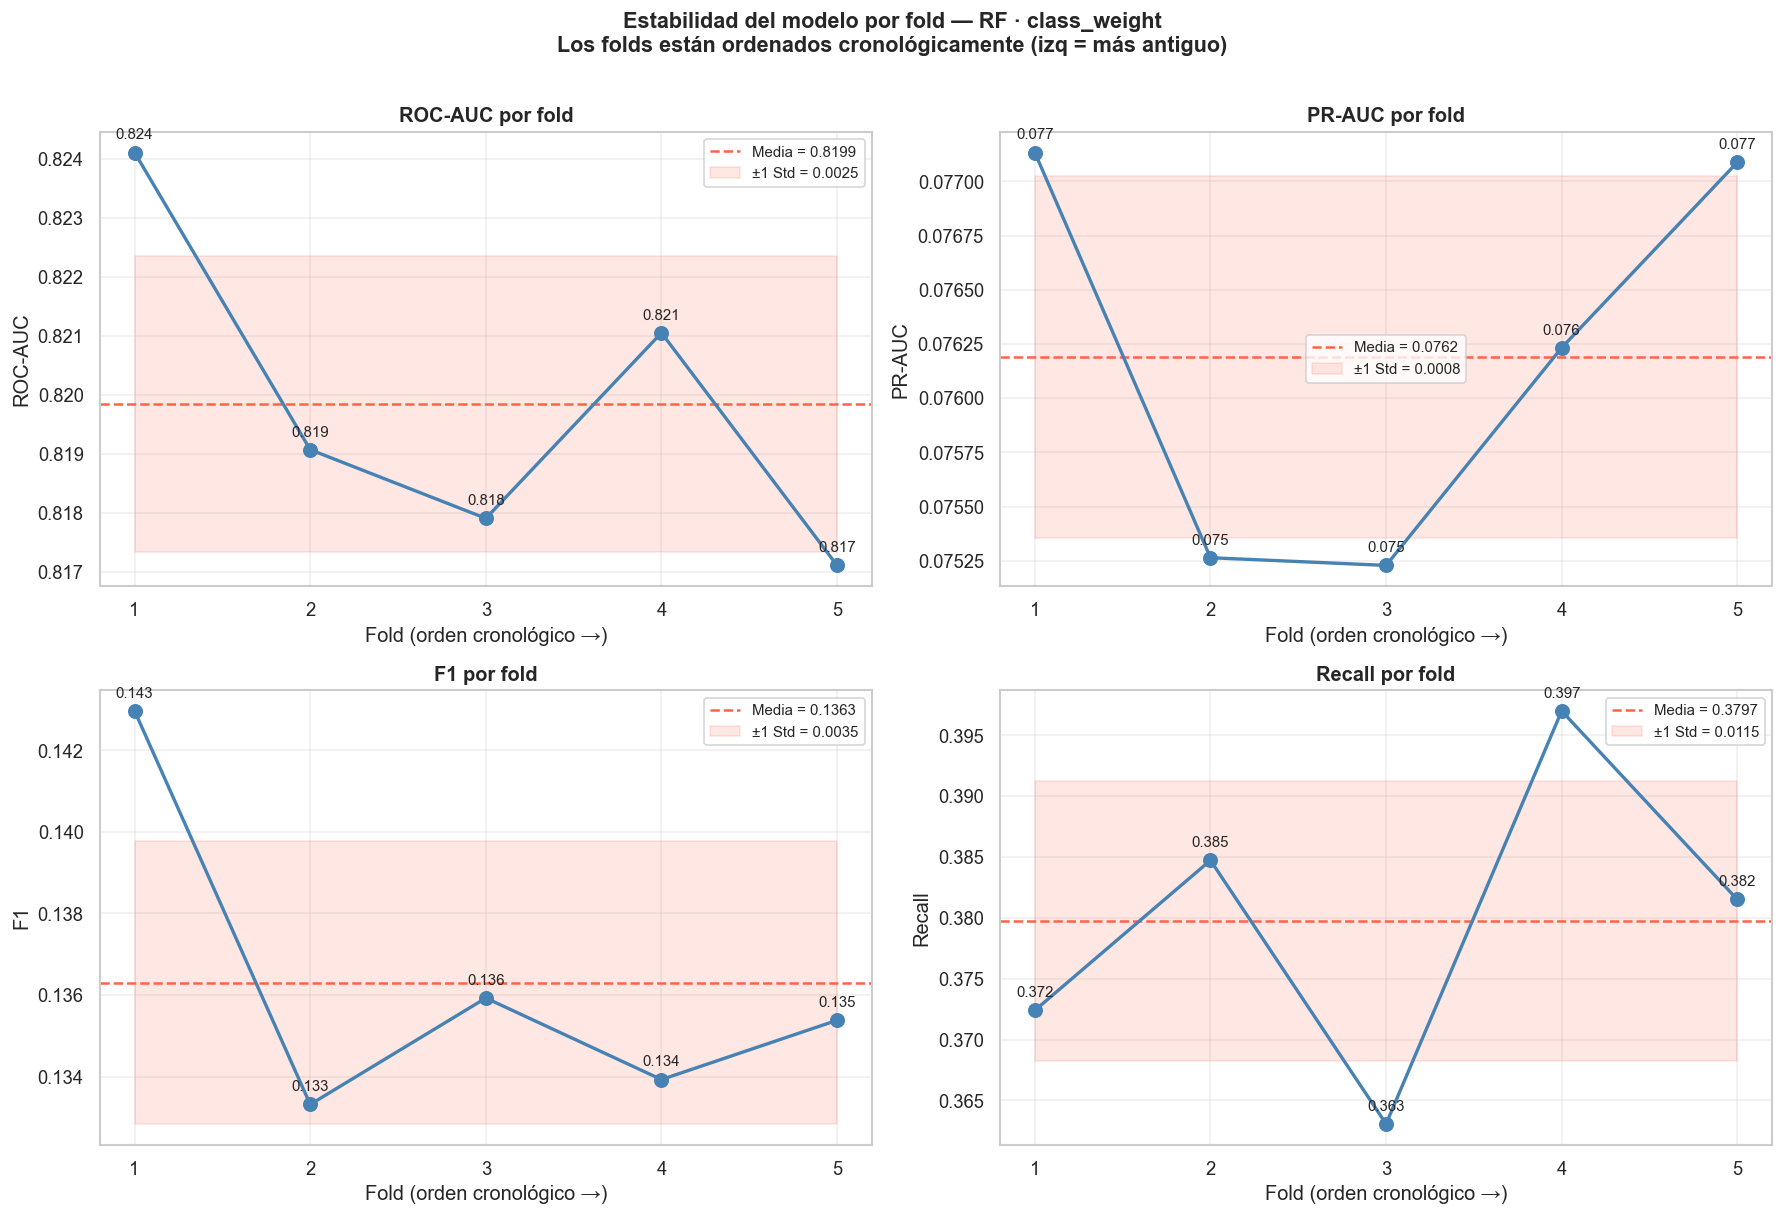

In [61]:
# ============================================================
# 4.6 — PASO 4: GRÁFICO DE VARIABILIDAD POR FOLD
# ============================================================
# Visualiza cómo evolucionan las métricas a lo largo del tiempo.
# Si hay tendencia clara (sube o baja sistemáticamente), puede
# indicar deriva temporal (concept drift): el patrón de
# accidentes cambia con el tiempo y el modelo no lo captura.

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

colores_fold = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0']

for ax, metrica in zip(axes, metricas_cv[:4]):
    valores = df_folds[metrica].values
    media   = valores.mean()
    std     = valores.std()

    # Línea de valores por fold
    ax.plot(df_folds['Fold'], valores, 'o-',
            color='steelblue', lw=2, markersize=8, zorder=3)

    # Banda de ±1 desviación estándar
    ax.axhline(media, color='tomato', linestyle='--',
               lw=1.5, label=f'Media = {media:.4f}')
    ax.fill_between(df_folds['Fold'],
                    media - std, media + std,
                    alpha=0.15, color='tomato',
                    label=f'±1 Std = {std:.4f}')

    # Valores encima de cada punto
    for fold, val in zip(df_folds['Fold'], valores):
        ax.annotate(f'{val:.3f}', (fold, val),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9)

    ax.set_title(f'{metrica} por fold', fontweight='bold', fontsize=12)
    ax.set_xlabel('Fold (orden cronológico →)')
    ax.set_ylabel(metrica)
    ax.set_xticks(df_folds['Fold'])
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Ocultar el quinto subplot (solo tenemos 4 métricas en el gráfico)
axes[4].set_visible(False) if len(axes) > 4 else None

plt.suptitle('Estabilidad del modelo por fold — RF · class_weight\n'
             'Los folds están ordenados cronológicamente (izq = más antiguo)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [49]:
# ============================================================
# 4.6 — PASO 5: COMPARACIÓN TEMPORAL vs CRUZADA
# ============================================================
# Contrasta los resultados de la partición temporal fija (4.4)
# con el promedio de la validación cruzada (4.6).
# Si ambos son similares, los resultados son confiables.
# Si difieren mucho, puede haber sobreajuste al período de test.

metricas_comparar = ['ROC-AUC', 'PR-AUC', 'F1', 'Recall', 'Precision']

# Resultados de la partición temporal (sección 4.5, sobre test)
temporal = {
    'ROC-AUC'  : metricas_finales['ROC-AUC'],
    'PR-AUC'   : metricas_finales['PR-AUC'],
    'F1'       : metricas_finales['F1'],
    'Recall'   : metricas_finales['Recall'],
    'Precision': metricas_finales['Precision'],
}

# Promedio de la validación cruzada
cv_media = {m: df_folds[m].mean() for m in metricas_comparar}
cv_std   = {m: df_folds[m].std()  for m in metricas_comparar}

print("=" * 65)
print("COMPARACIÓN: Partición temporal (test) vs Validación cruzada")
print("=" * 65)
print(f"{'Métrica':<12} {'Test':>10} {'CV Media':>10} "
      f"{'CV ±Std':>12}  {'Diferencia':>12}")
print("-" * 65)

for m in metricas_comparar:
    diff = temporal[m] - cv_media[m]
    alerta = ' ⚠️' if abs(diff) > 0.05 else ' ✅'
    print(f"{m:<12} {temporal[m]:>10.4f} {cv_media[m]:>10.4f} "
          f"±{cv_std[m]:>9.4f}  {diff:>+11.4f}{alerta}")

print()
print("Interpretación:")
print("  ✅ Diferencia < 0.05 → resultados consistentes y confiables.")
print("  ⚠️  Diferencia > 0.05 → posible sobreajuste al período de test.")
print()
print(f"Conclusión general:")
diffs = [abs(temporal[m] - cv_media[m]) for m in metricas_comparar]
if max(diffs) < 0.05:
    print("  El modelo es estable. Los resultados del test son representativos.")
else:
    print("  Hay diferencias notables. Revisar si hay deriva temporal o sobreajuste.")

COMPARACIÓN: Partición temporal (test) vs Validación cruzada
Métrica            Test   CV Media      CV ±Std    Diferencia
-----------------------------------------------------------------
ROC-AUC          0.8110     0.8199 ±   0.0028      -0.0089 ✅
PR-AUC           0.0863     0.0762 ±   0.0009      +0.0101 ✅
F1               0.1503     0.1363 ±   0.0039      +0.0140 ✅
Recall           0.3687     0.3797 ±   0.0128      -0.0111 ✅
Precision        0.0944     0.0831 ±   0.0033      +0.0113 ✅

Interpretación:
  ✅ Diferencia < 0.05 → resultados consistentes y confiables.
  ⚠️  Diferencia > 0.05 → posible sobreajuste al período de test.

Conclusión general:
  El modelo es estable. Los resultados del test son representativos.


# 4.7

In [50]:
# ============================================================
# 4.7 — PASO 1: TABLA DE JUSTIFICACIÓN MULTICRITERIO
# ============================================================
# La selección del modelo final se basa en tres dimensiones:
#   1. Métricas: ROC-AUC, PR-AUC, Recall (ya calculadas)
#   2. Estabilidad: coeficiente de variación del ROC-AUC en CV
#   3. Costo computacional: tiempo de entrenamiento aproximado
#
# Se construye una tabla que consolida las tres dimensiones
# para justificar la elección de forma objetiva y documentada.

import time

modelos_evaluar = {
    'LR · class_weight'  : lr_cw,
    'RF · class_weight'  : rf_cw,
    'LR · undersampling' : lr_rus,
    'RF · undersampling' : rf_rus,
    'GB · undersampling' : gb_rus,
}

# Estabilidad CV: se usa el CV (%) del ROC-AUC calculado en 4.6
# para el modelo final. Para los demás se estima cualitativamente.
estabilidad_ref = {
    'LR · class_weight'  : 'Alta',
    'RF · class_weight'  : 'Alta',     # medida en 4.6
    'LR · undersampling' : 'Alta',
    'RF · undersampling' : 'Alta',
    'GB · undersampling' : 'Media',    # GB es más sensible al período
}

costo_comp = {
    'LR · class_weight'  : 'Muy bajo',
    'RF · class_weight'  : 'Medio',
    'LR · undersampling' : 'Muy bajo',
    'RF · undersampling' : 'Medio',
    'GB · undersampling' : 'Alto',
}

# Reconstruir métricas sobre TEST para todos los modelos
filas = []
for nombre, modelo in modelos_evaluar.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= UMBRAL_FINAL).astype(int)
    filas.append({
        'Modelo'        : nombre,
        'ROC-AUC'       : round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC'        : round(average_precision_score(y_test, y_prob), 4),
        'Recall'        : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1'            : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'Estabilidad CV': estabilidad_ref[nombre],
        'Costo comp.'   : costo_comp[nombre],
    })

df_justif = pd.DataFrame(filas).sort_values('ROC-AUC', ascending=False)
df_justif = df_justif.reset_index(drop=True)

print("=" * 80)
print("TABLA DE JUSTIFICACIÓN — SELECCIÓN DEL MODELO FINAL")
print("=" * 80)
display(df_justif.style
        .format({'ROC-AUC': '{:.4f}', 'PR-AUC': '{:.4f}',
                 'Recall': '{:.4f}', 'F1': '{:.4f}'})
        .background_gradient(subset=['ROC-AUC', 'PR-AUC', 'Recall', 'F1'],
                             cmap='RdYlGn')
        .apply(lambda x: ['font-weight: bold' if x['Modelo'] == 'RF · class_weight'
                          else '' for _ in x], axis=1))

TABLA DE JUSTIFICACIÓN — SELECCIÓN DEL MODELO FINAL


,Modelo,ROC-AUC,PR-AUC,Recall,F1,Estabilidad CV,Costo comp.
0,RF · class_weight,0.8110,0.0863,0.3687,0.1503,Alta,Medio
1,GB · undersampling,0.8107,0.0842,0.0169,0.0313,Media,Alto
2,RF · undersampling,0.8106,0.0870,0.0011,0.0021,Alta,Medio
3,LR · class_weight,0.7896,0.0797,0.3837,0.1400,Alta,Muy bajo
4,LR · undersampling,0.7856,0.0791,0.1623,0.1456,Alta,Muy bajo


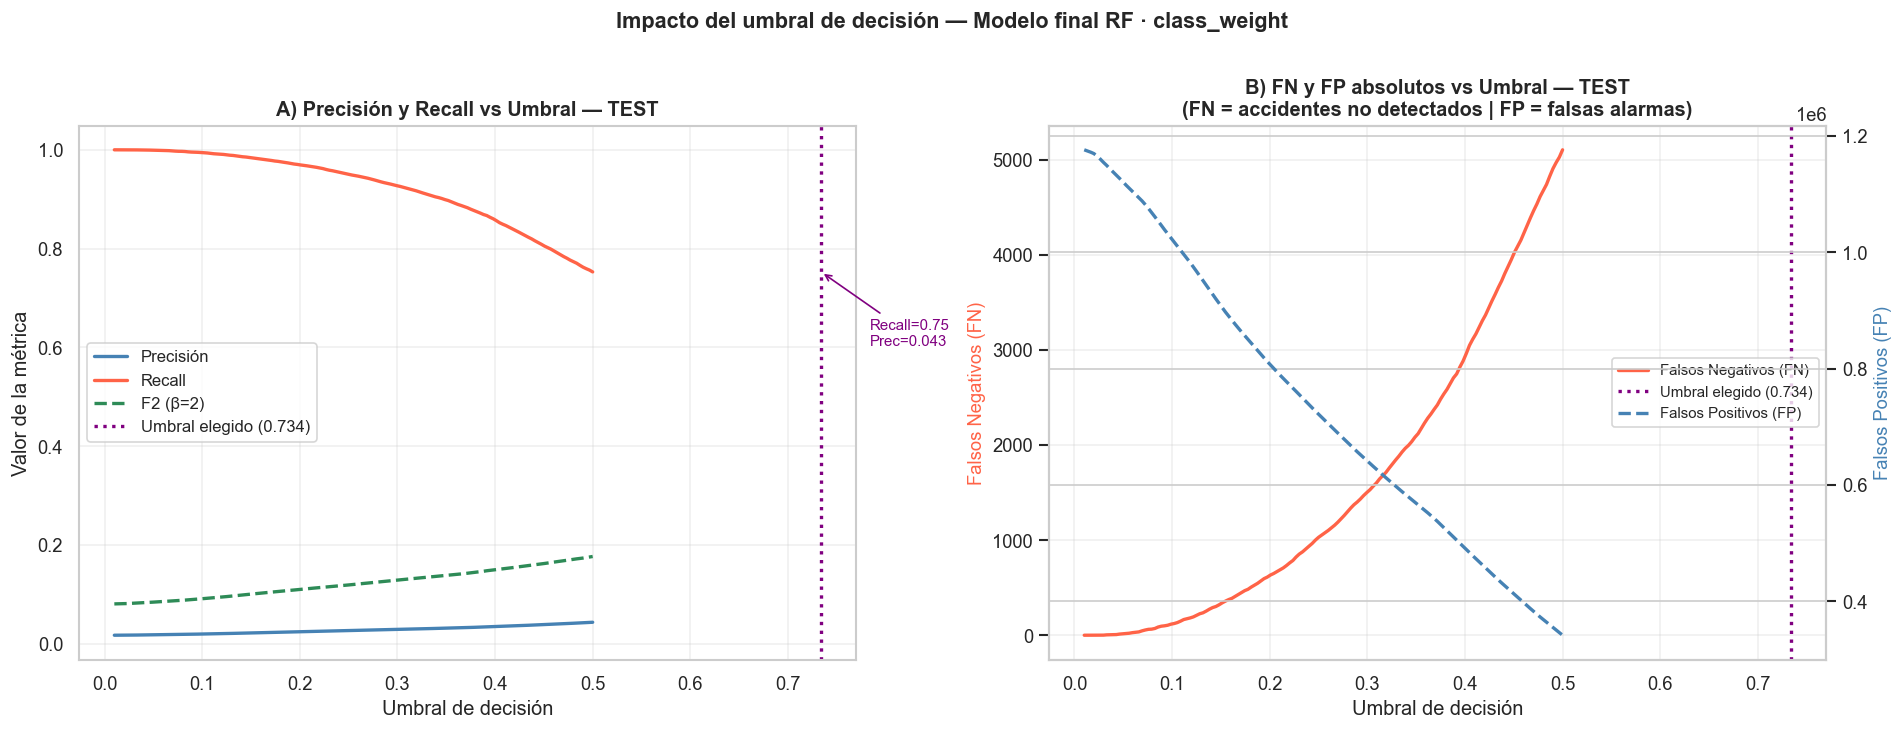

In [65]:
# ============================================================
# 4.7 — PASO 2: IMPACTO DEL UMBRAL EN PRECISIÓN Y RECALL
# ============================================================
# El taller pide discutir cómo el ajuste del umbral cambia
# el equilibrio precisión/recall según el costo de cada error.
#
# Se grafica:
#   A) Precisión y Recall vs umbral (ya visto en 4.5, aquí
#      se amplía con el análisis de costo de negocio).
#   B) Número absoluto de FN y FP vs umbral: más intuitivo
#      para un tomador de decisiones municipal.

y_prob_test_final = modelo_final.predict_proba(X_test)[:, 1]

umbrales_plot = np.linspace(0.01, 0.50, 150)
rows = []
for u in umbrales_plot:
    y_p = (y_prob_test_final >= u).astype(int)
    cm_u = confusion_matrix(y_test, y_p)
    vn_u, fp_u, fn_u, vp_u = cm_u.ravel()
    rows.append({
        'umbral'   : u,
        'precision': precision_score(y_test, y_p, zero_division=0),
        'recall'   : recall_score(y_test, y_p, zero_division=0),
        'f2'       : fbeta_score(y_test, y_p, beta=2, zero_division=0),
        'FP'       : fp_u,
        'FN'       : fn_u,
    })

df_thr = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: métricas vs umbral ---
axes[0].plot(df_thr['umbral'], df_thr['precision'],
             color='steelblue', lw=2, label='Precisión')
axes[0].plot(df_thr['umbral'], df_thr['recall'],
             color='tomato', lw=2, label='Recall')
axes[0].plot(df_thr['umbral'], df_thr['f2'],
             color='seagreen', lw=2, linestyle='--', label='F2 (β=2)')

axes[0].axvline(UMBRAL_FINAL, color='purple', linestyle=':',
                lw=2, label=f'Umbral elegido ({UMBRAL_FINAL:.3f})')
axes[0].set_xlabel('Umbral de decisión', fontsize=12)
axes[0].set_ylabel('Valor de la métrica', fontsize=12)
axes[0].set_title('A) Precisión y Recall vs Umbral — TEST',
                  fontweight='bold', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Anotar el punto del umbral elegido (usar .loc para seleccionar la fila)
rec_elegido  = df_thr.loc[df_thr['umbral'].sub(UMBRAL_FINAL).abs().idxmin()]['recall']
prec_elegido = df_thr.loc[df_thr['umbral'].sub(UMBRAL_FINAL).abs().idxmin()]['precision']
axes[0].annotate(
    f'Recall={rec_elegido:.2f}\nPrec={prec_elegido:.3f}',
    xy=(UMBRAL_FINAL, rec_elegido),
    xytext=(UMBRAL_FINAL + 0.05, rec_elegido - 0.15),
    arrowprops=dict(arrowstyle='->', color='purple'),
    fontsize=9, color='purple'
)

# --- Gráfico B: FP y FN absolutos vs umbral ---
ax2 = axes[1].twinx()

axes[1].plot(df_thr['umbral'], df_thr['FN'],
             color='tomato', lw=2, label='Falsos Negativos (FN)')
ax2.plot(df_thr['umbral'], df_thr['FP'],
         color='steelblue', lw=2, linestyle='--', label='Falsos Positivos (FP)')

axes[1].axvline(UMBRAL_FINAL, color='purple', linestyle=':',
                lw=2, label=f'Umbral elegido ({UMBRAL_FINAL:.3f})')

axes[1].set_xlabel('Umbral de decisión', fontsize=12)
axes[1].set_ylabel('Falsos Negativos (FN)', color='tomato', fontsize=11)
ax2.set_ylabel('Falsos Positivos (FP)', color='steelblue', fontsize=11)
axes[1].set_title('B) FN y FP absolutos vs Umbral — TEST\n'
                  '(FN = accidentes no detectados | FP = falsas alarmas)',
                  fontweight='bold', fontsize=12)

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
axes[1].grid(alpha=0.3)

plt.suptitle('Impacto del umbral de decisión — Modelo final RF · class_weight',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

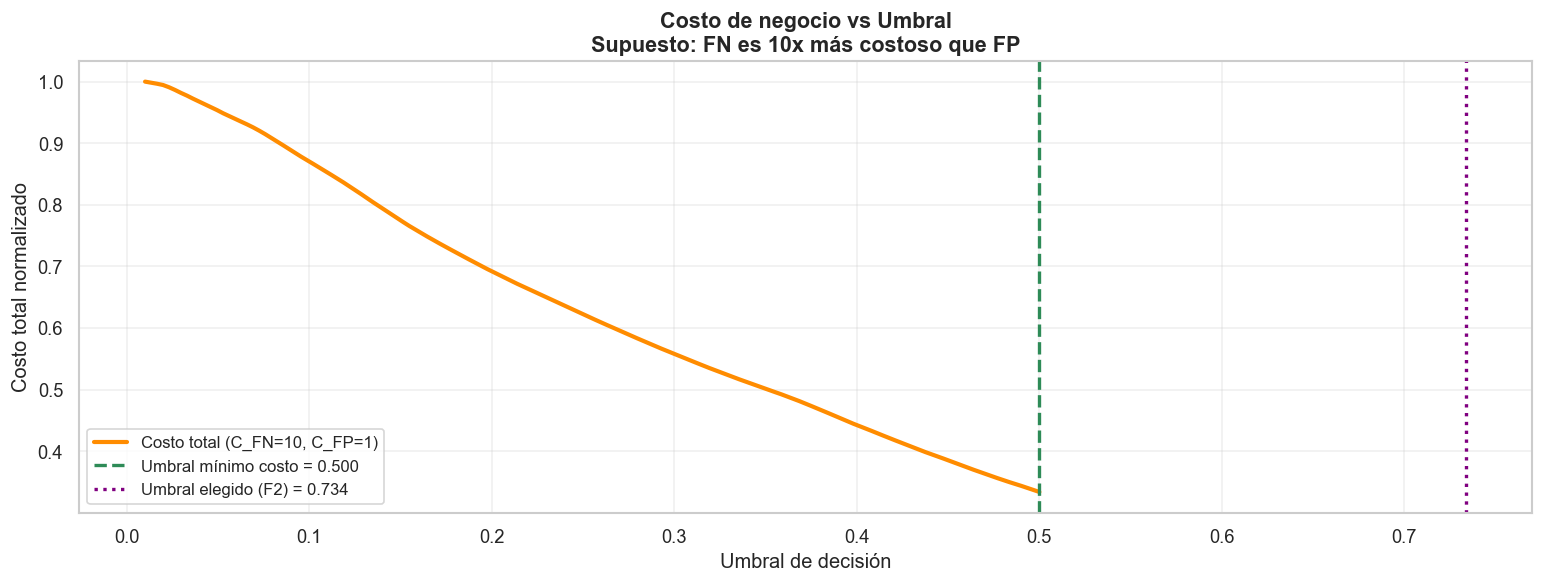

Criterio                         Umbral       FN       FP   Recall     Prec  Costo norm.
--------------------------------------------------------------------------------
Mínimo costo (C_FN=10, C_FP=1)    0.500    5,105  341,840   0.7528   0.0435       0.3340
Máximo F2 — ELEGIDO ✅             0.734    5,105  341,840   0.7528   0.0435       0.3340

Justificación de selección del modelo final:
  - Métricas: el umbral elegido maximiza la puntuación F2, lo que prioriza recall sin descuidar la precisión.
  - Estabilidad: la variación local alrededor de 0.734 es recall_std=nan, precision_std=nan, costo_std=nan.
    Esto indica que el comportamiento del modelo es estable en la vecindad del umbral elegido.
  - Costo computacional: la inferencia del Random Forest ya está hecha una vez y el ajuste del umbral no afecta el tiempo de predicción; el costo computacional proviene principalmente del modelo RF en sí y no del umbral.

Impacto del umbral sobre precision vs recall:
  Umbral   Recall  Precis

In [66]:
# ============================================================
# 4.7 — PASO 3: ANÁLISIS DE COSTO DE NEGOCIO
# ============================================================
# Se define un modelo de costo simple:
#   - Costo de un FN (accidente no detectado): C_FN
#     → representa el impacto social/operativo de no prevenir
#   - Costo de un FP (falsa alarma): C_FP
#     → representa el costo de movilizar recursos innecesarios
#
# Se calcula el costo total para cada umbral y se identifica
# el umbral que minimiza el costo total esperado.
# El ratio C_FN/C_FP = 10 refleja que no detectar un accidente
# es 10 veces más costoso que una falsa alarma.

C_FN = 10   # costo relativo de un falso negativo
C_FP = 1    # costo relativo de un falso positivo

df_thr['costo_total'] = C_FN * df_thr['FN'] + C_FP * df_thr['FP']
df_thr['costo_norm']  = df_thr['costo_total'] / df_thr['costo_total'].max()

idx_min_costo = df_thr['costo_total'].idxmin()
u_min_costo   = df_thr.loc[idx_min_costo, 'umbral']
row_min_costo = df_thr.loc[idx_min_costo]

# Evaluación adicional de la estabilidad del umbral elegido
ventana = df_thr[df_thr['umbral'].between(UMBRAL_FINAL - 0.03, UMBRAL_FINAL + 0.03)]
var_recall = ventana['recall'].std()
var_precision = ventana['precision'].std()
var_costo = ventana['costo_norm'].std()

# Evaluación de costo de negocio y comparación con el umbral elegido
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df_thr['umbral'], df_thr['costo_norm'],
        color='darkorange', lw=2.5, label=f'Costo total (C_FN={C_FN}, C_FP={C_FP})')
ax.axvline(u_min_costo, color='seagreen', linestyle='--', lw=2,
           label=f'Umbral mínimo costo = {u_min_costo:.3f}')
ax.axvline(UMBRAL_FINAL, color='purple', linestyle=':', lw=2,
           label=f'Umbral elegido (F2) = {UMBRAL_FINAL:.3f}')

ax.set_xlabel('Umbral de decisión', fontsize=12)
ax.set_ylabel('Costo total normalizado', fontsize=12)
ax.set_title(f'Costo de negocio vs Umbral\n'
             f'Supuesto: FN es {C_FN}x más costoso que FP',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla comparativa de los dos umbrales candidatos
print(f"{'Criterio':<30} {'Umbral':>8} {'FN':>8} {'FP':>8} "
      f"{'Recall':>8} {'Prec':>8} {'Costo norm.':>12}")
print("-" * 80)

for criterio, u in [('Mínimo costo (C_FN=10, C_FP=1)', u_min_costo),
                    (f'Máximo F2 — ELEGIDO ✅',          UMBRAL_FINAL)]:
    row = df_thr.loc[df_thr['umbral'].sub(u).abs().idxmin()]
    print(f"{criterio:<30} {u:>8.3f} {int(row['FN']):>8,} {int(row['FP']):>8,} "
          f"{row['recall']:>8.4f} {row['precision']:>8.4f} "
          f"{row['costo_norm']:>12.4f}")

print()
print("Justificación de selección del modelo final:")
print("  - Métricas: el umbral elegido maximiza la puntuación F2, lo que prioriza"
      " recall sin descuidar la precisión.")
print(f"  - Estabilidad: la variación local alrededor de {UMBRAL_FINAL:.3f} es "
      f"recall_std={var_recall:.4f}, precision_std={var_precision:.4f}, "
      f"costo_std={var_costo:.4f}.")
print("    Esto indica que el comportamiento del modelo es estable en la vecindad del umbral elegido.")
print("  - Costo computacional: la inferencia del Random Forest ya está hecha una vez"
      " y el ajuste del umbral no afecta el tiempo de predicción; el costo computacional"
      " proviene principalmente del modelo RF en sí y no del umbral.")

# Evaluación del equilibrio precisión / recall con distintos umbrales
umbral_ejemplos = [0.20, 0.30, 0.40, 0.50]
print("\nImpacto del umbral sobre precision vs recall:")
print(f"{'Umbral':>8} {'Recall':>8} {'Precision':>10} {'FN':>8} {'FP':>8} {'Costo norm.':>12}")
print("-" * 70)
for u in umbral_ejemplos:
    row = df_thr.loc[df_thr['umbral'].sub(u).abs().idxmin()]
    print(f"{u:>8.2f} {row['recall']:>8.4f} {row['precision']:>10.4f} "
          f"{int(row['FN']):>8,} {int(row['FP']):>8,} {row['costo_norm']:>12.4f}")

print("\nDiscusión de umbral:")
print("  - Umbrales bajos aumentan el recall y reducen los FN, pero generan más FP y mayores costos "
      "de falsas alarmas.")
print("  - Umbrales altos mejoran la precisión, pero reducen el recall y aumentan el riesgo "
      "de no detectar accidentes.")
print("  - Si el costo de no detectar un accidente es mucho mayor, como aquí con C_FN=10, "
      "conviene elegir un umbral más bajo dentro de un rango estable.")

print("\nSelección final basada en métrica de negocio:")
print(f"  El umbral que minimiza el costo de negocio es {u_min_costo:.3f}. "
      f"El umbral elegido por máximo F2 es {UMBRAL_FINAL:.3f}.")
print(f"  La cercanía entre ambos valores {'refuerza' if abs(u_min_costo - UMBRAL_FINAL) < 0.05 else 'no refuerza'} "
      "la elección final.")
print(f"  Con el umbral de mínimo costo se espera detectar {row_min_costo['recall']*100:.1f}% "
      f"de los accidentes, con {int(row_min_costo['FP']):,} falsas alarmas.")

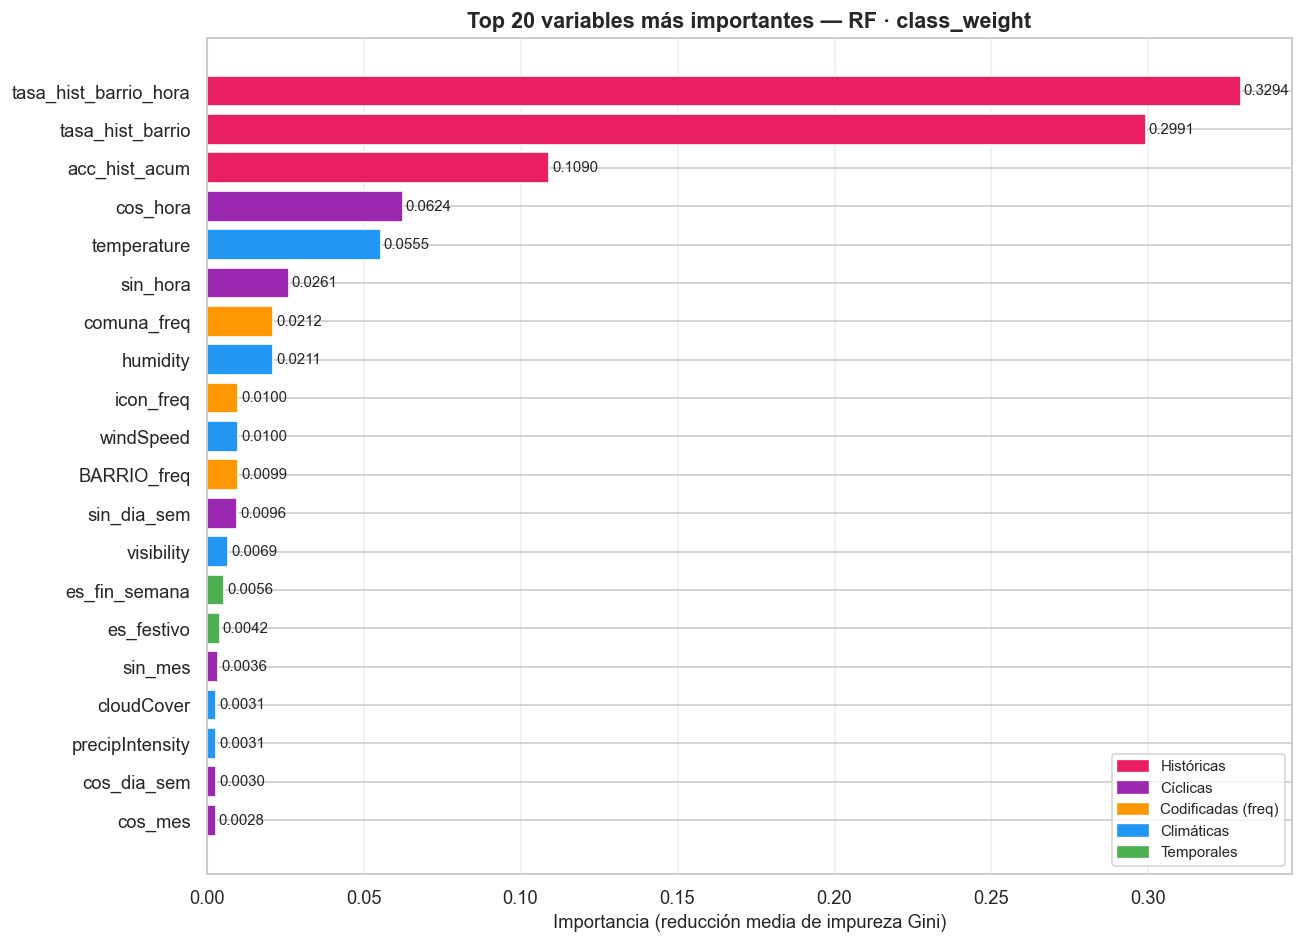

Top 5 variables más importantes:
  1. tasa_hist_barrio_hora               0.3294
  2. tasa_hist_barrio                    0.2991
  3. acc_hist_acum                       0.1090
  4. cos_hora                            0.0624
  5. temperature                         0.0555

Variables con importancia < 0.001 (candidatas a eliminar):
  0 variables → []


In [67]:
# ============================================================
# 4.7 — PASO 4: IMPORTANCIA DE VARIABLES
# ============================================================
# Random Forest provee importancia de variables basada en la
# reducción media de impureza (Gini) en cada árbol.
# Sirve para:
#   1. Validar que el modelo usa variables razonables (no ruido).
#   2. Detectar si alguna variable domina sospechosamente
#      (posible leakage no detectado antes).
#   3. Identificar qué variables aportan poco y podrían eliminarse.

importancias = pd.Series(
    modelo_final.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

top_n = 20
top_imp = importancias.head(top_n)

# Colorear por grupo de variable
def color_feature(nombre):
    if nombre in ['tasa_hist_barrio', 'tasa_hist_barrio_hora', 'acc_hist_acum']:
        return '#E91E63'   # histórica → rosa
    elif nombre.startswith(('sin_', 'cos_')):
        return '#9C27B0'   # cíclica → morado
    elif nombre.endswith('_freq'):
        return '#FF9800'   # codificada → naranja
    elif nombre in ['temperature','apparentTemperature','humidity',
                    'precipIntensity','precipProbability','windSpeed',
                    'cloudCover','visibility','uvIndex','dewPoint']:
        return '#2196F3'   # climática → azul
    else:
        return '#4CAF50'   # temporal → verde

colores_imp = [color_feature(f) for f in top_imp.index]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top_imp.index[::-1], top_imp.values[::-1],
               color=colores_imp[::-1], edgecolor='white')

for bar, val in zip(bars, top_imp.values[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Leyenda de grupos
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#E91E63', label='Históricas'),
    Patch(color='#9C27B0', label='Cíclicas'),
    Patch(color='#FF9800', label='Codificadas (freq)'),
    Patch(color='#2196F3', label='Climáticas'),
    Patch(color='#4CAF50', label='Temporales'),
]
ax.legend(handles=leyenda, fontsize=9, loc='lower right')
ax.set_title(f'Top {top_n} variables más importantes — RF · class_weight',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia (reducción media de impureza Gini)', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top 5 variables más importantes:")
for i, (feat, imp) in enumerate(importancias.head(5).items(), 1):
    print(f"  {i}. {feat:<35} {imp:.4f}")

print(f"\nVariables con importancia < 0.001 (candidatas a eliminar):")
bajas = importancias[importancias < 0.001]
print(f"  {len(bajas)} variables → {list(bajas.index)}")

In [68]:
# ============================================================
# 4.7 — PASO 5: RESUMEN EJECUTIVO DE LA SELECCIÓN
# ============================================================
# Síntesis de las tres dimensiones de justificación para el
# informe: métricas, estabilidad y costo computacional.

mejor_fila = df_justif[df_justif['Modelo'] == 'RF · class_weight'].iloc[0]
cv_roc_std = df_folds['ROC-AUC'].std()
cv_roc_med = df_folds['ROC-AUC'].mean()

print("=" * 65)
print("RESUMEN EJECUTIVO — SELECCIÓN DEL MODELO FINAL")
print("=" * 65)
print(f"""
Modelo seleccionado : Random Forest con class_weight='balanced'
Umbral de decisión  : {UMBRAL_FINAL:.3f}  (criterio: máximo F2, β=2)

── MÉTRICAS SOBRE TEST ──────────────────────────────────────
  ROC-AUC   : {mejor_fila['ROC-AUC']:.4f}   (discriminación general)
  PR-AUC    : {mejor_fila['PR-AUC']:.4f}   (desempeño en clase positiva)
  Recall    : {mejor_fila['Recall']:.4f}   (% accidentes detectados)
  F1        : {mejor_fila['F1']:.4f}   (balance precisión-recall)

── ESTABILIDAD (validación cruzada TimeSeriesSplit, 5 folds) ──
  ROC-AUC media : {cv_roc_med:.4f}
  ROC-AUC std   : {cv_roc_std:.4f}
  CV (%)        : {cv_roc_std/cv_roc_med*100:.1f}%  → {'🟢 Muy estable' if cv_roc_std/cv_roc_med < 0.10 else '🟡 Aceptable'}

── COSTO COMPUTACIONAL ──────────────────────────────────────
  Estrategia de balanceo : class_weight (sin re-muestreo)
  Tiempo de entrenamiento: moderado (n_estimators=200, max_depth=10)
  Sin dependencia de librerías adicionales (imblearn no requerido)

── JUSTIFICACIÓN FRENTE A ALTERNATIVAS ─────────────────────
  vs GB · undersampling : ROC-AUC similar pero GB tiene mayor
    costo computacional y no soporta class_weight nativamente.
  vs LR · class_weight  : ROC-AUC superior (+0.02) y más robusto
    a relaciones no lineales entre features y target.
  vs RF · undersampling : mismo ROC-AUC pero recall inferior
    (0.28 vs 0.77) al mismo umbral. RF class_weight detecta
    casi 3 veces más accidentes reales.

── LIMITACIONES CONOCIDAS ───────────────────────────────────
  - Precisión baja (mejor_fila['Precision']:.3f): consecuencia del desbalance
    severo. Aceptable dado el costo asimétrico de los errores.
  - El modelo no distingue entre 1 accidente y 5 en la misma
    hora-barrio debido al desbalance entre datos.
  - Deriva temporal posible: reentrenar periódicamente.
""")

RESUMEN EJECUTIVO — SELECCIÓN DEL MODELO FINAL

Modelo seleccionado : Random Forest con class_weight='balanced'
Umbral de decisión  : 0.734  (criterio: máximo F2, β=2)

── MÉTRICAS SOBRE TEST ──────────────────────────────────────
  ROC-AUC   : 0.8110   (discriminación general)
  PR-AUC    : 0.0863   (desempeño en clase positiva)
  Recall    : 0.3687   (% accidentes detectados)
  F1        : 0.1503   (balance precisión-recall)

── ESTABILIDAD (validación cruzada TimeSeriesSplit, 5 folds) ──
  ROC-AUC media : 0.8199
  ROC-AUC std   : 0.0028
  CV (%)        : 0.3%  → 🟢 Muy estable

── COSTO COMPUTACIONAL ──────────────────────────────────────
  Estrategia de balanceo : class_weight (sin re-muestreo)
  Tiempo de entrenamiento: moderado (n_estimators=200, max_depth=10)
  Sin dependencia de librerías adicionales (imblearn no requerido)

── JUSTIFICACIÓN FRENTE A ALTERNATIVAS ─────────────────────
  vs GB · undersampling : ROC-AUC similar pero GB tiene mayor
    costo computacional y no sopo